In [1]:
import os
import re
import numpy as np
import matplotlib.pyplot as plt

# import tqdm
# from tqdm import tqdm
from tqdm.notebook import tqdm
import pickle


## Read in each data file

## Plot verification of the K(phi) solutions

## Extracting vertex data

## Turn into ML-ready datasets

### Block parameters are listed as:
- height factor
- thickness
- radius
- W/r
- crack number
- ndom
- a/c
- a/t
- r/t
- b/t
- c

In [2]:
# Define full ML dataset indices for easier readability and slicing
height_factor_idx = 0  # Remove, variance=0
thickness_idx = 1
radius_idx = 2  # Remove, variance=0
w_over_r_idx = 3
crack_number_idx = 4
ndom_idx = 5
a_over_c_idx = 6
a_over_t_idx = 7
R_over_t_idx = 8
b_over_t_idx = 9  # Remove, variance=0
c_idx = 10
Ktension_c_idx = 11
Kbending_c_idx = 12
Kbearing_c_idx = 13
Ktension_a_idx = 14
Kbending_a_idx = 15
Kbearing_a_idx = 16

# Create a dictionary that maps variable name strings to the index variables
dataset_index_mapping = {
    "height_factor_idx": height_factor_idx,
    "thickness_idx": thickness_idx,
    "radius_idx": radius_idx,
    "w_over_r_idx": w_over_r_idx,
    "crack_number_idx": crack_number_idx,
    "ndom_idx": ndom_idx,
    "a_over_c_idx": a_over_c_idx,
    "a_over_t_idx": a_over_t_idx,
    "R_over_t_idx": R_over_t_idx,
    "b_over_t_idx": b_over_t_idx,
    "c_idx": c_idx,
    "Ktension_c_idx": Ktension_c_idx,
    "Kbending_c_idx": Kbending_c_idx,
    "Kbearing_c_idx": Kbearing_c_idx,
    "Ktension_a_idx": Ktension_a_idx,
    "Kbending_a_idx": Kbending_a_idx,
    "Kbearing_a_idx": Kbearing_a_idx,
}

In [3]:
def build_reduction_dicts_from_array(all_params_all_Ks_with_reference, dataset_index_mapping):
    """
    Build reduction dictionaries from numpy array dataset.
    
    This function creates reduction dictionaries by fixing 3 parameters and varying 1,
    for all possible combinations. Each dictionary contains the free parameter data,
    K-factor data, and vertex flags.
    
    Parameters:
    -----------
    all_params_all_Ks_with_reference : np.ndarray
        Full dataset array with reference index column appended
    dataset_index_mapping : dict
        Dictionary mapping index names to column indices
        
    Returns:
    --------
    list of dict : reduction_dicts
        List of reduction dictionaries, each containing:
        - 'data_indices': Original indices from full dataset
        - 'free_param_name': Name of the varying parameter
        - Fixed parameter names with their values
        - 'data': Dict with arrays for free_param_data, K-factors, and vertex flags
    """
    # Find unique values for each parameter
    unique_w_over_r = np.unique(all_params_all_Ks_with_reference[:, dataset_index_mapping['w_over_r_idx']])
    unique_a_over_c = np.unique(all_params_all_Ks_with_reference[:, dataset_index_mapping['a_over_c_idx']])
    unique_a_over_t = np.unique(all_params_all_Ks_with_reference[:, dataset_index_mapping['a_over_t_idx']])
    unique_R_over_t = np.unique(all_params_all_Ks_with_reference[:, dataset_index_mapping['R_over_t_idx']])
    
    # print("Unique w/r values:", unique_w_over_r)
    # print("Unique a/c values:", unique_a_over_c)
    # print("Unique a/t values:", unique_a_over_t)
    # print("Unique R/t values:", unique_R_over_t)
    
    # Define feature information
    feature_names = ['w_over_r', 'a_over_c', 'a_over_t', 'R_over_t']
    feature_indices = [
        dataset_index_mapping['w_over_r_idx'],
        dataset_index_mapping['a_over_c_idx'],
        dataset_index_mapping['a_over_t_idx'],
        dataset_index_mapping['R_over_t_idx']
    ]
    feature_unique_values = [unique_w_over_r, unique_a_over_c, unique_a_over_t, unique_R_over_t]
    
    reduction_dicts = []
    
    for i in range(len(feature_names)):
        remaining_feature_names = [feature_names[j] for j in range(len(feature_names)) if j != i]
        remaining_feature_indices = [feature_indices[j] for j in range(len(feature_names)) if j != i]
        remaining_feature_unique_values = [feature_unique_values[j] for j in range(len(feature_names)) if j != i]
        
        combined_mask = []
        for fixed_feature_0 in tqdm(remaining_feature_unique_values[0], 
                                    desc=f"Building reductions for {feature_names[i]}"):
            for fixed_feature_1 in remaining_feature_unique_values[1]:
                for fixed_feature_2 in remaining_feature_unique_values[2]:
                    mask_feature_0 = np.isclose(all_params_all_Ks_with_reference[:, remaining_feature_indices[0]], fixed_feature_0)
                    mask_feature_1 = np.isclose(all_params_all_Ks_with_reference[:, remaining_feature_indices[1]], fixed_feature_1)
                    mask_feature_2 = np.isclose(all_params_all_Ks_with_reference[:, remaining_feature_indices[2]], fixed_feature_2)
                    mask_list = [mask_feature_0, mask_feature_1, mask_feature_2]
                    
                    combined_mask = np.logical_and.reduce(mask_list)
                    filtered_data_fixed_params = all_params_all_Ks_with_reference[combined_mask]
                    
                    # Skip if no data points found
                    if filtered_data_fixed_params.shape[0] == 0:
                        continue

                    # Skip if less than 3 data points found
                    if filtered_data_fixed_params.shape[0] < 4:
                        continue

                    # Sort the free_param data
                    sort_idx = np.argsort(filtered_data_fixed_params[:, feature_indices[i]])

                    # Build data dictionary
                    data_dict = {
                        "all_consensus_outliers_removed": False,
                        "requires_outlier_detection": True,
                        "data_indices": filtered_data_fixed_params[:, -1][sort_idx].astype(int),
                        "free_param_name": feature_names[i],
                        remaining_feature_names[0]: fixed_feature_0,
                        remaining_feature_names[1]: fixed_feature_1,
                        remaining_feature_names[2]: fixed_feature_2,
                        "data": {
                            "free_param_data": filtered_data_fixed_params[:, feature_indices[i]][sort_idx],
                            "Ktension_c_data": filtered_data_fixed_params[:, dataset_index_mapping['Ktension_c_idx']][sort_idx],
                            "Kbending_c_data": filtered_data_fixed_params[:, dataset_index_mapping['Kbending_c_idx']][sort_idx],
                            "Kbearing_c_data": filtered_data_fixed_params[:, dataset_index_mapping['Kbearing_c_idx']][sort_idx],
                            "Ktension_a_data": filtered_data_fixed_params[:, dataset_index_mapping['Ktension_a_idx']][sort_idx],
                            "Kbending_a_data": filtered_data_fixed_params[:, dataset_index_mapping['Kbending_a_idx']][sort_idx],
                            "Kbearing_a_data": filtered_data_fixed_params[:, dataset_index_mapping['Kbearing_a_idx']][sort_idx],
                            "Ktension_c_vertex_flag": filtered_data_fixed_params[:, dataset_index_mapping['Ktension_c_idx'] + 6][sort_idx],
                            "Kbending_c_vertex_flag": filtered_data_fixed_params[:, dataset_index_mapping['Kbending_c_idx'] + 6][sort_idx],
                            "Kbearing_c_vertex_flag": filtered_data_fixed_params[:, dataset_index_mapping['Kbearing_c_idx'] + 6][sort_idx],
                            "Ktension_a_vertex_flag": filtered_data_fixed_params[:, dataset_index_mapping['Ktension_a_idx'] + 6][sort_idx],
                            "Kbending_a_vertex_flag": filtered_data_fixed_params[:, dataset_index_mapping['Kbending_a_idx'] + 6][sort_idx],
                            "Kbearing_a_vertex_flag": filtered_data_fixed_params[:, dataset_index_mapping['Kbearing_a_idx'] + 6][sort_idx],
                        },
                    }

                    reduction_dicts.append(data_dict)
    
    print(f"\nCreated {len(reduction_dicts)} reduction dictionaries")
    return reduction_dicts


# all_params_all_Ks = np.load('all_params_all_Ks_vertex_flagged.npy')
# # Add an index column for easier reference
# print(all_params_all_Ks.shape)
# all_params_all_Ks_with_reference = np.column_stack([all_params_all_Ks, np.arange(len(all_params_all_Ks))])
# print(all_params_all_Ks_with_reference.shape)

# # Call the function with the index mapping
# reduction_dicts = build_reduction_dicts_from_array(
#     all_params_all_Ks_with_reference=all_params_all_Ks_with_reference,
#     dataset_index_mapping=dataset_index_mapping
# )

# with open("reduction_dicts.pkl", "wb") as f:
#     pickle.dump(reduction_dicts, f)

In [4]:
def build_fixed_param_mapping(reduction_dicts):
    """
    Build a mapping array of fixed parameter values for each reduction dictionary.
    
    Creates a 2D numpy array where each row corresponds to a reduction_dict and contains
    the values of all 4 parameters [w_over_r, a_over_c, a_over_t, R_over_t].
    The free parameter for each curve is marked with np.nan.
    
    Parameters:
    -----------
    reduction_dicts : list of dict
        List of reduction dictionaries created by build_reduction_dicts_from_array
        
    Returns:
    --------
    np.ndarray : fixed_param_mapping
        Shape (n_curves, 4) array with parameter values
        Columns: [w_over_r, a_over_c, a_over_t, R_over_t]
        Free parameter position contains np.nan
    """
    fixed_param_mapping = []
    
    for i in range(len(reduction_dicts)):
        row_fixed_params = []
        if reduction_dicts[i]["free_param_name"] == "w_over_r":
            row_fixed_params.append(np.nan)
            row_fixed_params.append(reduction_dicts[i]["a_over_c"])
            row_fixed_params.append(reduction_dicts[i]["a_over_t"])
            row_fixed_params.append(reduction_dicts[i]["R_over_t"])
        elif reduction_dicts[i]["free_param_name"] == "a_over_c":
            row_fixed_params.append(reduction_dicts[i]["w_over_r"])
            row_fixed_params.append(np.nan)
            row_fixed_params.append(reduction_dicts[i]["a_over_t"])
            row_fixed_params.append(reduction_dicts[i]["R_over_t"])
        elif reduction_dicts[i]["free_param_name"] == "a_over_t":
            row_fixed_params.append(reduction_dicts[i]["w_over_r"])
            row_fixed_params.append(reduction_dicts[i]["a_over_c"])
            row_fixed_params.append(np.nan)
            row_fixed_params.append(reduction_dicts[i]["R_over_t"])
        elif reduction_dicts[i]["free_param_name"] == "R_over_t":
            row_fixed_params.append(reduction_dicts[i]["w_over_r"])
            row_fixed_params.append(reduction_dicts[i]["a_over_c"])
            row_fixed_params.append(reduction_dicts[i]["a_over_t"])
            row_fixed_params.append(np.nan)
        
        fixed_param_mapping.append(row_fixed_params)
    
    fixed_param_mapping = np.array(fixed_param_mapping)
    
    print("Fixed parameter mapping array shape:", fixed_param_mapping.shape)
    return fixed_param_mapping


# Build the fixed parameter mapping
# fixed_param_mapping = build_fixed_param_mapping(reduction_dicts)

In [23]:
def filter_w_over_r_datapoints(reduction_dicts, max_w_over_r=50):
    """
    Remove individual data points where w/r > max_w_over_r when w_over_r is the free parameter.
    
    For curves where w_over_r is the free parameter, this function removes any data points
    where the w/r value exceeds max_w_over_r. The curve itself is kept as long as it has
    at least 4 remaining data points after filtering.
    
    Parameters:
    -----------
    reduction_dicts : list of dict
        List of reduction dictionaries to filter
    max_w_over_r : float, optional
        Maximum allowed w/r value when w/r is the free parameter (default: 50)
        
    Returns:
    --------
    list of dict : filtered_reduction_dicts
        Reduction dictionaries with data points removed where w/r > max_w_over_r
        Curves with fewer than 4 remaining points are also removed
    """
    initial_curves = len(reduction_dicts)
    total_points_before = sum(len(d["data"]["free_param_data"]) for d in reduction_dicts)
    
    filtered_reduction_dicts = []
    n_points_removed = 0
    n_curves_removed = 0
    
    for d in reduction_dicts:
        # Check if w_over_r is the free parameter
        if d["free_param_name"] == "w_over_r":
            # Get w/r values (which are the free parameter values)
            w_over_r_values = d["data"]["free_param_data"]
            
            # Create mask for points to keep (w/r <= max_w_over_r)
            keep_mask = w_over_r_values <= max_w_over_r
            n_points_to_remove = (~keep_mask).sum()
            
            if n_points_to_remove > 0:
                # Filter all data arrays using the keep mask
                d["data"]["free_param_data"] = d["data"]["free_param_data"][keep_mask]
                d["data_indices"] = d["data_indices"][keep_mask]
                
                # Filter all K-target data arrays
                for key in d["data"].keys():
                    if key != "free_param_data":  # Already filtered above
                        d["data"][key] = d["data"][key][keep_mask]
                
                n_points_removed += n_points_to_remove
            
            # Check if curve still has enough points after filtering
            if len(d["data"]["free_param_data"]) < 4:
                n_curves_removed += 1
                continue  # Skip this curve - not enough points left
        
        # Keep this curve (either not w/r free param, or has enough points after filtering)
        filtered_reduction_dicts.append(d)
    
    total_points_after = sum(len(d["data"]["free_param_data"]) for d in filtered_reduction_dicts)
    
    print(f"Filtered w/r data points:")
    print(f"  Curves before: {initial_curves}")
    print(f"  Curves after: {len(filtered_reduction_dicts)}")
    print(f"  Curves removed (< 4 points after filtering): {n_curves_removed}")
    print(f"  Total data points before: {total_points_before}")
    print(f"  Total data points after: {total_points_after}")
    print(f"  Data points removed (w/r > {max_w_over_r}): {n_points_removed}")
    if total_points_before > 0:
        print(f"  Percentage of points removed: {100*n_points_removed/total_points_before:.2f}%")
    
    return filtered_reduction_dicts


# Usage example:
# reduction_dicts = filter_w_over_r_datapoints(reduction_dicts, max_w_over_r=30)

In [5]:
def filter_reduction_dicts_by_w_over_r(reduction_dicts, fixed_param_mapping, max_w_over_r=50):
    """
    Filter reduction dictionaries to only include curves where w/r <= max_w_over_r
    when w_over_r is the free parameter.
    
    Uses the fixed_param_mapping array where column 0 is w_over_r values (np.nan if free param).
    Only filters curves where w_over_r is the free parameter (column 0 = np.nan).
    
    Parameters:
    -----------
    reduction_dicts : list of dict
        List of reduction dictionaries to filter
    fixed_param_mapping : np.ndarray
        Array of shape (n_curves, 4) with columns [w_over_r, a_over_c, a_over_t, R_over_t]
        Free parameter marked with np.nan
    max_w_over_r : float, optional
        Maximum allowed w/r value when w/r is the free parameter (default: 50)
        
    Returns:
    --------
    tuple : (filtered_reduction_dicts, filtered_fixed_param_mapping)
        Both filtered to exclude w/r curves with values > max_w_over_r
    """
    initial_length = len(reduction_dicts)
    
    # Create mask: keep if (w_over_r is NOT free param) OR (w_over_r is free and all values <= max)
    mask_keep = np.ones(len(reduction_dicts), dtype=bool)
    
    for i in range(len(reduction_dicts)):
        # Check if w_over_r is the free parameter (column 0 is NaN)
        if np.isnan(fixed_param_mapping[i, 0]):
            # w_over_r is free - check if all values are within limit
            w_over_r_values = reduction_dicts[i]["data"]["free_param_data"]
            if not np.all(w_over_r_values <= max_w_over_r):
                mask_keep[i] = False
    
    # Apply filter to both reduction_dicts and fixed_param_mapping
    filtered_reduction_dicts = [reduction_dicts[i] for i in range(len(reduction_dicts)) if mask_keep[i]]
    filtered_fixed_param_mapping = fixed_param_mapping[mask_keep]
    
    print(f"Filtered reduction_dicts: {len(filtered_reduction_dicts)} curves retained (from {initial_length})")
    print(f"Removed {initial_length - len(filtered_reduction_dicts)} curves with w/r (as free param) > {max_w_over_r}")
    
    return filtered_reduction_dicts, filtered_fixed_param_mapping


# # Apply filtering
# reduction_dicts, fixed_param_mapping = filter_reduction_dicts_by_w_over_r(
#     reduction_dicts, fixed_param_mapping, max_w_over_r=50
# )

## Simple Polynomial Fitting for Curve Quality Assessment

In [6]:
def simple_polynomial_fit(x, y, min_degree=2, max_degree=5, min_points=4):
    """
    Fit polynomials of degrees min_degree to max_degree and select the best based on R².
    
    Parameters:
    -----------
    x : array-like
        Independent variable
    y : array-like
        Dependent variable
    min_degree : int
        Minimum polynomial degree to try (default: 2)
    max_degree : int
        Maximum polynomial degree to try (default: 5)
    min_points : int
        Minimum number of valid points required (default: 4)
    
    Returns:
    --------
    dict with keys:
        - 'best_degree': Selected polynomial degree
        - 'best_r2': R² value of best fit
        - 'best_rmse': RMSE of best fit
        - 'coeffs': Polynomial coefficients of best fit
        - 'y_pred': Predicted y values
        - 'all_fits': Dict with results for each degree tried
        - 'is_bad_fit': Boolean indicating poor fit quality
        - 'n_points': Number of valid data points
    """
    from sklearn.metrics import r2_score, mean_squared_error
    
    result = {
        'best_degree': None,
        'best_r2': -np.inf,
        'best_rmse': np.inf,
        'coeffs': None,
        'y_pred': None,
        'all_fits': {},
        'is_bad_fit': True,
        'n_points': 0
    }
    
    # Input validation
    if x is None or y is None or len(x) < min_points:
        return result
    
    x_array = np.array(x)
    y_array = np.array(y)
    
    # Remove NaN/Inf values
    valid_mask = np.isfinite(x_array) & np.isfinite(y_array)
    if valid_mask.sum() < min_points:
        return result
    
    x_clean = x_array[valid_mask]
    y_clean = y_array[valid_mask]
    
    # Sort by x
    sort_idx = np.argsort(x_clean)
    x_sorted = x_clean[sort_idx]
    y_sorted = y_clean[sort_idx]
    x_sorted = x_array  # Removing sort dependency
    y_sorted = y_array
    
    result['n_points'] = len(x_sorted)

    # Additional check: need at least 2 points for R² calculation
    if len(x_sorted) < 2:
        return result
    
    # Try each polynomial degree
    max_feasible_degree = min(max_degree, len(x_sorted) - 1)
    
    for degree in range(min_degree, max_feasible_degree + 1):
        # Skip if we don't have enough points for this degree
        if len(x_sorted) < degree + 1:
            continue

        try:
            # Fit polynomial
            coeffs = np.polyfit(x_sorted, y_sorted, degree)
            y_pred = np.polyval(coeffs, x_sorted)
            
            # Calculate metrics
            r2 = r2_score(y_sorted, y_pred)
            mse = mean_squared_error(y_sorted, y_pred)
            rmse = np.sqrt(mse)
            
            # Store results for this degree
            result['all_fits'][degree] = {
                'r2': float(r2),
                'rmse': float(rmse),
                'coeffs': coeffs.tolist()
            }
            
            # Update best fit (with small penalty for higher degrees to avoid overfitting)
            adjusted_r2 = r2 - 0.001 * degree
            
            if adjusted_r2 > result['best_r2']:
                result['best_degree'] = degree
                result['best_r2'] = float(r2)
                result['best_rmse'] = float(rmse)
                result['coeffs'] = coeffs.tolist()
                result['y_pred'] = y_pred
                
        except Exception as e:
            result['all_fits'][degree] = {'error': str(e)}
            continue
    
    # Determine if fit is bad
    if result['best_r2'] is not None and result['best_r2'] > 0.5:
        result['is_bad_fit'] = False
    
    return result


# Test the function
print("=== Testing Simple Polynomial Fit Function ===\n")

# Test with quadratic data
test_x = np.array([1, 2, 3, 4, 5, 6, 7, 8])
test_y = np.array([1.0, 4.1, 9.0, 16.2, 24.9, 36.1, 49.0, 64.2])

result = simple_polynomial_fit(test_x, test_y, min_degree=2, max_degree=5)

print(f"Best degree: {result['best_degree']}")
print(f"Best R²: {result['best_r2']:.4f}")
print(f"Best RMSE: {result['best_rmse']:.4f}")
print(f"Is bad fit: {result['is_bad_fit']}")
print(f"\nAll fits tried:")
for degree, fit_info in result['all_fits'].items():
    if 'error' not in fit_info:
        print(f"  Degree {degree}: R² = {fit_info['r2']:.4f}, RMSE = {fit_info['rmse']:.4f}")
    else:
        print(f"  Degree {degree}: Error - {fit_info['error']}")

print("\n=== Function ready for use! ===")

=== Testing Simple Polynomial Fit Function ===

Best degree: 2
Best R²: 1.0000
Best RMSE: 0.0942
Is bad fit: False

All fits tried:
  Degree 2: R² = 1.0000, RMSE = 0.0942
  Degree 3: R² = 1.0000, RMSE = 0.0824
  Degree 4: R² = 1.0000, RMSE = 0.0818
  Degree 5: R² = 1.0000, RMSE = 0.0815

=== Function ready for use! ===
Best degree: 2
Best R²: 1.0000
Best RMSE: 0.0942
Is bad fit: False

All fits tried:
  Degree 2: R² = 1.0000, RMSE = 0.0942
  Degree 3: R² = 1.0000, RMSE = 0.0824
  Degree 4: R² = 1.0000, RMSE = 0.0818
  Degree 5: R² = 1.0000, RMSE = 0.0815

=== Function ready for use! ===


In [29]:
def detect_polynomial_outliers(x, y, poly_degree, method='ransac', threshold=3.5, pct_error_threshold=25.0, 
                               robust_fit=False, max_iter=100):
    """
    Detect outliers in polynomial fit using residual-based or Cook's distance methods.
    
    Parameters:
    -----------
    x : array-like
        Independent variable
    y : array-like
        Dependent variable
    poly_degree : int
        Degree of polynomial to fit
    method : str
        Outlier detection method:
        - 'mad': Modified z-score using Median Absolute Deviation
        - 'cooks': Cook's distance (influence of each point on fit)
        - 'huber': Huber regression (robust to outliers)
        - 'ransac': RANSAC polynomial fitting
    threshold : float
        Threshold for outlier detection
        - For 'mad': Modified z-score threshold (default 3.5)
        - For 'cooks': Cook's distance threshold (default 3.5, or use 4/n rule)
        - For 'huber': residual threshold for Huber loss (default 3.5)
        - For 'ransac': residual threshold for inliers (default 3.5)
    pct_error_threshold : float
        Percentage error threshold for MAD method (default 25.0)
        A point must exceed BOTH the z-score threshold AND this percentage error
        to be classified as an outlier. Only applies to 'mad' method.
    robust_fit : bool
        If True, use robust regression (Huber) for initial fit in MAD/Cook's methods
        This helps when outliers distort the initial polynomial fit (default False)
    max_iter : int
        Maximum iterations for iterative methods like Huber (default 100)
    
    Returns:
    --------
    dict with keys:
        - 'outlier_mask': Boolean array indicating outliers (True = outlier)
        - 'outlier_indices': Indices of outliers
        - 'scores': Detection scores for each point (modified z-score or Cook's D)
        - 'threshold_used': Actual threshold used
        - 'pct_error_threshold_used': Percentage error threshold used (MAD only)
        - 'pct_errors': Percentage errors for each point (MAD only)
        - 'coeffs': Polynomial coefficients of full fit
        - 'n_outliers': Number of outliers detected
        - 'method': Method used
        - 'robust_fit_used': Whether robust fitting was used
    """
    from sklearn.linear_model import HuberRegressor, RANSACRegressor
    from sklearn.preprocessing import PolynomialFeatures
    from sklearn.pipeline import make_pipeline
    
    result = {
        'outlier_mask': None,
        'outlier_indices': [],
        'scores': None,
        'threshold_used': threshold,
        'pct_error_threshold_used': pct_error_threshold if method == 'mad' else None,
        'pct_errors': None,
        'coeffs': None,
        'n_outliers': 0,
        'method': method,
        'robust_fit_used': robust_fit or method in ['huber', 'ransac']
    }
    
    # Input validation
    if x is None or y is None or len(x) < poly_degree + 2:
        return result
    
    x_array = np.array(x)
    y_array = np.array(y)
    
    # Remove NaN/Inf values
    valid_mask = np.isfinite(x_array) & np.isfinite(y_array)
    if valid_mask.sum() < poly_degree + 2:
        return result
    
    x_clean = x_array[valid_mask]
    y_clean = y_array[valid_mask]
    n = len(x_clean)
    
    # Reshape for sklearn
    X = x_clean.reshape(-1, 1)
    
    # Fit initial polynomial
    try:
        if method == 'ransac':
            # RANSAC fitting
            # FIXED: More conservative min_samples calculation
            # Use at least degree+1 points, but cap at 50-70% of data
            # This prevents requiring too many samples on small datasets
            min_samples_lower = poly_degree + 2
            min_samples_upper = max(min_samples_lower, int(0.5 * n))  # Changed from 0.6 to 0.5
            min_samples = min(min_samples_upper, n - 1)  # Never use all points
            
            # Additional check: if min_samples would be too restrictive, use simpler approach
            if min_samples > n - 2:
                min_samples = min(poly_degree + 1, max(2, n // 2))

            # Calculate residual threshold as a PERCENTILE of residuals from initial fit
            # This is much more robust than using MAD
            # try:
            #     # Quick initial fit to estimate scale
            #     initial_coeffs = np.polyfit(x_clean, y_clean, poly_degree)
            #     initial_pred = np.polyval(initial_coeffs, x_clean)
            #     initial_residuals = np.abs(y_clean - initial_pred)
                
            #     # Use 75th percentile of residuals as threshold (adaptive to data)
            #     residual_threshold = np.percentile(initial_residuals, 67.5) * threshold
            #     # pass
            # except:
            #     # Fallback to MAD approach
            #     mad_y = np.median(np.abs(y_clean - np.median(y_clean)))
            #     if mad_y == 0:
            #         mad_y = np.std(y_clean)
            #     residual_threshold = threshold * mad_y

            

            ransac = make_pipeline(
                PolynomialFeatures(poly_degree, include_bias=False),
                RANSACRegressor(
                    min_samples=min_samples,
                    # residual_threshold=residual_threshold,
                    max_trials=10000,
                    random_state=42,
                )
            )

            ransac.fit(X, y_clean)
            y_pred = ransac.predict(X)
            

            # Get inlier mask from RANSAC
            ransac_model = ransac.named_steps['ransacregressor']
            inlier_mask = ransac_model.inlier_mask_
            outlier_mask = ~inlier_mask
            
            # ADDITIONAL CHECK: If too few inliers, mark as invalid
            n_inliers = inlier_mask.sum()
            if n_inliers < 2:
                # Can't calculate R² with fewer than 2 points
                result['outlier_mask'] = np.zeros(n, dtype=bool)
                result['n_outliers'] = 0
                result['coeffs'] = None
                result['scores'] = np.zeros(n)
                return result
            
            # Extract coefficients
            coeffs_sklearn = np.concatenate([[ransac_model.estimator_.intercept_], 
                                            ransac_model.estimator_.coef_])

            coeffs = coeffs_sklearn[::-1]
            
            residuals = y_clean - y_pred
            result['coeffs'] = coeffs.tolist()
            result['outlier_mask'] = outlier_mask
            result['outlier_indices'] = np.where(outlier_mask)[0].tolist()
            result['n_outliers'] = outlier_mask.sum()
            result['scores'] = np.abs(residuals)  # Use absolute residuals as scores
            
            return result
            
        else:
            raise ValueError(f"Unknown method: {method}. Use 'mad', 'cooks', 'huber', or 'ransac'")
            
    except Exception as e:
        print(f"Error fitting polynomial: {e}")
        return result
    
    return result

In [8]:
def run_ransac_parameter_sweep(reduction_dicts, K_targets=None, 
                               min_degree=3, max_degree=4,
                               min_threshold=1.0, max_threshold=2.5, threshold_step=0.5,
                               max_to_analyze=33000, N_skip=1, clean_previous_results=True):
    """
    Run RANSAC parameter sweep on reduction dictionaries.
    
    For each curve and K-target, sweeps over polynomial degrees and threshold values
    to find the best RANSAC outlier detection configuration. Results are stored in
    each reduction_dict under 'ransac_sweep_results'.
    
    Parameters:
    -----------
    reduction_dicts : list of dict
        List of reduction dictionaries to analyze
    K_targets : list of str, optional
        K-factor target names to analyze (default: ["Kbearing_c_data", "Kbearing_a_data"])
    min_degree, max_degree : int
        Range of polynomial degrees to test (default: 3-4)
    min_threshold, max_threshold : float
        Range of RANSAC threshold values to test (default: 1.0-2.5)
    threshold_step : float
        Step size for threshold sweep (default: 0.5)
    max_to_analyze : int
        Maximum number of curves to analyze (default: 33000)
    N_skip : int
        Analyze every Nth curve (default: 1 = analyze all)
    clean_previous_results : bool
        If True, delete existing ransac_sweep_results before running (default: True)
        
    Returns:
    --------
    dict : Summary statistics including:
        - analyzed_count: Number of curves analyzed
        - warnings_count: Number of configs with insufficient inliers
        - total_configs_tested: Total parameter combinations tested
        - best_degree_counts: Distribution of best degrees
        - best_threshold_counts: Distribution of best thresholds
        - r2_values_best: List of R² values for best configs
        - outlier_counts_best: List of outlier counts for best configs
    """
    import warnings
    warnings.filterwarnings('ignore', category=UserWarning, module='sklearn')
    print("=== Analyzing Curves with RANSAC Parameter Sweep ===\n")
    
    # Set default K_targets if not provided
    if K_targets is None:
        K_targets = ["Kbearing_c_data", "Kbearing_a_data"]
    
    # Clean previous RANSAC results if requested
    if clean_previous_results:
        for d in reduction_dicts:
            if "ransac_sweep_results" in d:
                del d["ransac_sweep_results"]
    
    analyzed_count = 0
    warnings_count = 0
    
    # Create progress bar
    pbar = tqdm(total=min(max_to_analyze, len(reduction_dicts)), 
                desc="Analyzing curves", 
                unit="curve")
    
    for curve_idx, d in enumerate(reduction_dicts):
        
        pbar.update(1)
        pbar.set_postfix({'warnings': warnings_count})

        if analyzed_count >= max_to_analyze:
            break
        
        if curve_idx % N_skip != 0 and curve_idx > 0:
            continue  # Skip to reduce total number analyzed for speed
        
        data_block = d["data"]
        x = np.array(data_block["free_param_data"])
        
        # Check if we have sufficient data points
        if len(x) < 4:
            continue
        
        # Initialize ransac_sweep_results if not present
        if "ransac_sweep_results" not in d:
            d["ransac_sweep_results"] = {}
        
        # Analyze each K target
        has_valid_results = False
        for k_target in K_targets:
            if k_target not in data_block:
                continue
            
            y = np.array(data_block[k_target])
            
            # Clean and sort data
            valid_mask = np.isfinite(x) & np.isfinite(y)
            if valid_mask.sum() < 4:
                continue
            
            x_clean = x[valid_mask]
            y_clean = y[valid_mask]
            # sort_idx = np.argsort(x_clean)
            # x_sorted = x_clean[sort_idx]
            # y_sorted = y_clean[sort_idx]
            
            # Initialize storage for this K target
            sweep_results = {
                'degree_threshold_grid': {},
                'best_config': None,
                'best_r2': -np.inf,
                'best_n_outliers': None
            }
            
            # Sweep over polynomial degrees
            for poly_degree in range(min_degree, max_degree + 1):
                # Check if we have enough points for this degree
                # if len(x_xsorted) < poly_degree + 1:
                if len(x) < poly_degree + 1:
                    continue
                

                sweep_results['degree_threshold_grid'][poly_degree] = {}
                
                # Sweep over thresholds
                threshold_values = np.arange(min_threshold, max_threshold + threshold_step/2, threshold_step)
                
                for threshold in threshold_values:
                    try:
                        # Run RANSAC outlier detection
                        outlier_result = detect_polynomial_outliers(
                            # x_sorted, y_sorted, 
                            x, y,
                            poly_degree, 
                            method='ransac', 
                            threshold=threshold
                        )
                        
                        # Calculate R² on inliers if we have a valid fit
                        r2_inliers = -np.inf
                        n_inliers = 0
                        
                        if (outlier_result['coeffs'] is not None and 
                            outlier_result['outlier_mask'] is not None):
                            
                            inlier_mask = ~outlier_result['outlier_mask']
                            n_inliers = inlier_mask.sum()
                            
                            # Need at least 2 inliers AND at least degree+1 points for meaningful R²
                            min_inliers_needed = max(2, poly_degree + 1)
                            
                            if n_inliers >= min_inliers_needed:
                                from sklearn.metrics import r2_score
                                # y_inliers = y_sorted[inlier_mask]
                                # x_inliers = x_sorted[inlier_mask]
                                y_inliers = y[inlier_mask]
                                x_inliers = x[inlier_mask]
                                y_pred_inliers = np.polyval(outlier_result['coeffs'], x_inliers)
                                
                                # Only calculate R² if predictions are valid
                                if np.all(np.isfinite(y_pred_inliers)):
                                    r2_inliers = r2_score(y_inliers, y_pred_inliers)
                                else:
                                    warnings_count += 1
                            else:
                                # Too few inliers - this configuration is too aggressive
                                warnings_count += 1
                        
                        # Store results for this configuration
                        config_result = {
                            'outlier_result': outlier_result,
                            'r2_inliers': float(r2_inliers),
                            'n_inliers': int(n_inliers),
                            'threshold': float(threshold)
                        }
                        
                        sweep_results['degree_threshold_grid'][poly_degree][float(threshold)] = config_result
                        
                        # Update best configuration (prioritize R² on inliers)
                        # Only consider configs with enough inliers
                        min_inliers_for_best = max(2, poly_degree + 1)
                        if n_inliers >= min_inliers_for_best and r2_inliers > sweep_results['best_r2']:
                            sweep_results['best_r2'] = float(r2_inliers)
                            sweep_results['best_n_outliers'] = outlier_result['n_outliers']
                            sweep_results['best_config'] = {
                                'degree': poly_degree,
                                'threshold': float(threshold),
                                'outlier_result': outlier_result,
                                'r2_inliers': float(r2_inliers),
                                'n_inliers': int(n_inliers)
                            }
                        
                    except Exception as e:
                        print("CHECKPOINT 2")
                        print(e)
                        # Store error information
                        sweep_results['degree_threshold_grid'][poly_degree][float(threshold)] = {
                            'error': str(e)
                        }
                        continue
            
            # Store the sweep results
            d["ransac_sweep_results"][k_target] = sweep_results
            
            if sweep_results['best_config'] is not None:
                has_valid_results = True
        
        if has_valid_results:
            analyzed_count += 1
            
    
    pbar.close()
    
    print(f"\n{'='*80}")
    print(f"Analysis complete! Analyzed {analyzed_count} curves.")
    print(f"Configurations with too few inliers: {warnings_count}")
    print(f"{'='*80}")
    
    # Print summary statistics
    total_configs_tested = 0
    best_degree_counts = {}
    best_threshold_counts = {}
    r2_values_best = []
    outlier_counts_best = []
    
    for d in reduction_dicts[:analyzed_count]:
        if "ransac_sweep_results" not in d:
            continue
        
        for k_target, sweep_result in d["ransac_sweep_results"].items():
            # Count total configurations tested
            for degree, threshold_dict in sweep_result['degree_threshold_grid'].items():
                total_configs_tested += len(threshold_dict)
            
            # Track best configuration statistics
            if sweep_result['best_config'] is not None:
                best_config = sweep_result['best_config']
                
                degree = best_config['degree']
                best_degree_counts[degree] = best_degree_counts.get(degree, 0) + 1
                
                threshold = best_config['threshold']
                best_threshold_counts[threshold] = best_threshold_counts.get(threshold, 0) + 1
                
                r2_values_best.append(best_config['r2_inliers'])
                outlier_counts_best.append(best_config['outlier_result']['n_outliers'])
    
    print(f"\nSummary Statistics:")
    print(f"  Total parameter configurations tested: {total_configs_tested}")
    print(f"  Curves with valid best configuration: {len(r2_values_best)}")
    
    if r2_values_best:
        print(f"\nR² Statistics (on inliers for best config):")
        print(f"  Mean R²: {np.mean(r2_values_best):.4f}")
        print(f"  Median R²: {np.median(r2_values_best):.4f}")
        print(f"  Min R²: {np.min(r2_values_best):.4f}")
        print(f"  Max R²: {np.max(r2_values_best):.4f}")
    
    if best_degree_counts:
        print(f"\nBest Polynomial Degree Distribution:")
        for degree in sorted(best_degree_counts.keys()):
            count = best_degree_counts[degree]
            print(f"  Degree {degree}: {count} fits ({100*count/len(r2_values_best):.1f}%)")
    
    if best_threshold_counts:
        print(f"\nBest Threshold Distribution:")
        for threshold in sorted(best_threshold_counts.keys()):
            count = best_threshold_counts[threshold]
            print(f"  Threshold {threshold:.1f}: {count} fits ({100*count/len(r2_values_best):.1f}%)")
    
    if outlier_counts_best:
        print(f"\nOutlier Detection Statistics (best config):")
        print(f"  Total outliers detected: {sum(outlier_counts_best)}")
        print(f"  Fits with outliers: {sum(1 for count in outlier_counts_best if count > 0)} ({100*sum(1 for count in outlier_counts_best if count > 0)/len(outlier_counts_best):.1f}%)")
        print(f"  Mean outliers per fit: {np.mean(outlier_counts_best):.2f}")
        print(f"  Max outliers in a fit: {max(outlier_counts_best)}")
    
    # Return summary statistics
    return {
        'analyzed_count': analyzed_count,
        'warnings_count': warnings_count,
        'total_configs_tested': total_configs_tested,
        'best_degree_counts': best_degree_counts,
        'best_threshold_counts': best_threshold_counts,
        'r2_values_best': r2_values_best,
        'outlier_counts_best': outlier_counts_best
    }


# # Run the RANSAC parameter sweep
# sweep_stats = run_ransac_parameter_sweep(
#     reduction_dicts,
#     K_targets=["Kbearing_c_data", "Kbearing_a_data"],
#     min_degree=3,
#     max_degree=4,
#     min_threshold=1.0,
#     max_threshold=2.5,
#     threshold_step=0.5,
#     max_to_analyze=33000,
#     N_skip=100,  # For testing; set to 1 to analyze all
#     clean_previous_results=True
# )

## Iterative RANSAC Outlier Removal

This cell performs iterative outlier detection and removal:
1. Build reduction dictionaries from data
2. Run RANSAC parameter sweep
3. Identify consensus outliers across parameter combinations
4. Remove a percentage of consensus outliers
5. Repeat the process

This progressive refinement helps remove outliers that distort polynomial fits.

In [19]:
import copy
import time

def update_outlier_detection_flags(current_reduction_dicts, previous_reduction_dicts, 
                                   indices_removed_last_iter, consensus_threshold):
    """
    Update 'requires_outlier_detection' flag for curves based on previous iteration results.
    
    For each curve in current_reduction_dicts, checks if ALL consensus outliers from the
    previous iteration were removed. If yes, sets requires_outlier_detection=False since
    the curve should now be clean.
    
    Parameters:
    -----------
    current_reduction_dicts : list of dict
        Current iteration's reduction dictionaries
    previous_reduction_dicts : list of dict
        Previous iteration's reduction dictionaries
    indices_removed_last_iter : set
        Global data indices that were removed in the previous iteration
        
    Returns:
    --------
    int : Number of curves flagged as not requiring outlier detection
    """
    n_curves_flagged_clean = 0
    
    print(f"  Checking {len(current_reduction_dicts)} curves against previous iteration...")
    
    for curr_d in current_reduction_dicts:
        # Default to requiring outlier detection
        curr_d['requires_outlier_detection'] = True
        
        # Extract identifying parameters for this curve
        curr_free_param = curr_d['free_param_name']
        curr_fixed_params = {
            'w_over_r': curr_d.get('w_over_r'),
            'a_over_c': curr_d.get('a_over_c'),
            'a_over_t': curr_d.get('a_over_t'),
            'R_over_t': curr_d.get('R_over_t')
        }
        
        # Find matching curve in previous iteration
        matching_prev_d = None
        for prev_d in previous_reduction_dicts:
            # Check if free parameter matches
            if prev_d['free_param_name'] != curr_free_param:
                continue
            
            # Check if fixed parameters match
            params_match = True
            for param, value in curr_fixed_params.items():
                if value is None:  # This is the free parameter
                    continue
                prev_value = prev_d.get(param)
                if prev_value is None or not np.isclose(value, prev_value, rtol=1e-5):
                    params_match = False
                    break
            
            if params_match:
                matching_prev_d = prev_d
                break
        
        # If no match found in previous iteration, curve is new (shouldn't happen)
        if matching_prev_d is None:
            continue
        
        # Check if previous curve had RANSAC results with consensus outliers
        if 'ransac_sweep_results' not in matching_prev_d:
            continue
        
        # For each K-target, check if all consensus outliers were removed
        all_outliers_removed = True
        
        for k_target in matching_prev_d['ransac_sweep_results'].keys():
            sweep_result = matching_prev_d['ransac_sweep_results'][k_target]
            
            # Skip if no valid RANSAC results
            if 'degree_threshold_grid' not in sweep_result:
                continue
            
            # Get the data_indices from previous iteration's curve
            prev_data_indices = matching_prev_d['data_indices']
            
            # Calculate consensus outliers for previous iteration
            # (similar to find_consensus_outliers but for single curve)
            degree_threshold_grid = sweep_result['degree_threshold_grid']
            
            # Get data size
            data_block = matching_prev_d["data"]
            x_prev = np.array(data_block["free_param_data"])
            y_prev = np.array(data_block.get(k_target, []))
            
            if len(y_prev) == 0:
                continue
            
            valid_mask = np.isfinite(x_prev) & np.isfinite(y_prev)
            n_points = valid_mask.sum()
            
            if n_points < 4:
                continue
            
            # Count outlier votes
            outlier_votes = np.zeros(n_points, dtype=int)
            total_configs = 0
            
            for poly_degree, threshold_dict in degree_threshold_grid.items():
                for threshold, config_result in threshold_dict.items():
                    if 'error' in config_result:
                        continue
                    
                    outlier_result = config_result.get('outlier_result', {})
                    outlier_mask = outlier_result.get('outlier_mask')
                    
                    if outlier_mask is not None:
                        outlier_votes += outlier_mask.astype(int)
                        total_configs += 1
            
            if total_configs == 0:
                continue
            
            # Calculate consensus outliers (using same threshold as main loop)
            # NOTE: Using CONSENSUS_THRESHOLD from main configuration
            outlier_fraction = outlier_votes / total_configs
            consensus_mask = outlier_fraction >= consensus_threshold
            
            # Get global indices of consensus outliers
            consensus_outlier_global_indices = set()
            for local_idx, is_consensus_outlier in enumerate(consensus_mask):
                if is_consensus_outlier:
                    global_idx = prev_data_indices[local_idx]
                    consensus_outlier_global_indices.add(global_idx)
            
            # Check if all consensus outliers were removed
            if len(consensus_outlier_global_indices) > 0:
                outliers_not_removed = consensus_outlier_global_indices - indices_removed_last_iter
                
                if len(outliers_not_removed) > 0:
                    # Not all consensus outliers were removed
                    all_outliers_removed = False
                    break
        
        # Set flag based on whether all outliers were removed
        if all_outliers_removed:
            curr_d['requires_outlier_detection'] = False
            n_curves_flagged_clean += 1
    
    print(f"  Flagged {n_curves_flagged_clean} curves as not requiring outlier detection")
    
    return n_curves_flagged_clean


def find_consensus_outliers(reduction_dicts, K_targets, consensus_threshold=0.5):
    """
    Find outliers that are consistently detected across multiple RANSAC parameter combinations.
    
    Parameters:
    -----------
    reduction_dicts : list of dicts
        Reduction dictionaries with RANSAC results
    K_targets : list
        K-factor target names
    consensus_threshold : float
        Fraction of parameter combinations that must agree (0.5 = majority vote)
        
    Returns:
    --------
    dict : Mapping from curve_idx to dict of consensus outlier info
    """
    consensus_outliers = {}
    
    for curve_idx, d in enumerate(reduction_dicts):
        if "ransac_sweep_results" not in d:
            continue
        
        for k_target in K_targets:
            if k_target not in d["ransac_sweep_results"]:
                continue
            
            sweep_result = d["ransac_sweep_results"][k_target]
            degree_threshold_grid = sweep_result['degree_threshold_grid']
            
            # Get data size
            data_block = d["data"]
            x = np.array(data_block["free_param_data"])
            y = np.array(data_block[k_target])
            valid_mask = np.isfinite(x) & np.isfinite(y)
            n_points = valid_mask.sum()
            
            if n_points < 4:
                continue
            
            # Count how many configs mark each point as outlier
            outlier_votes = np.zeros(n_points, dtype=int)
            total_configs = 0
            
            for poly_degree, threshold_dict in degree_threshold_grid.items():
                for threshold, config_result in threshold_dict.items():
                    if 'error' in config_result:
                        continue
                    
                    outlier_result = config_result['outlier_result']
                    if outlier_result['outlier_mask'] is not None:
                        outlier_votes += outlier_result['outlier_mask'].astype(int)
                        total_configs += 1
            
            if total_configs == 0:
                continue
            
            # Calculate consensus: fraction of configs that marked each point as outlier
            outlier_fraction = outlier_votes / total_configs
            consensus_mask = outlier_fraction >= consensus_threshold
            
            # Print out the consensus mask
            # Print out the associated Kbearing_c data
            # print(f"  Associated Kbearing_c data for curve {curve_idx}, Free param {d['free_param_name']}:")
            # print(f"    {data_block['Kbearing_c_data'][valid_mask][consensus_mask]}")

            if consensus_mask.sum() > 0:
                key = (curve_idx, k_target)
                consensus_outliers[key] = {
                    'consensus_mask': consensus_mask,
                    'outlier_fraction': outlier_fraction,
                    'n_consensus_outliers': consensus_mask.sum(),
                    'total_configs': total_configs
                }
    
    return consensus_outliers


def extract_global_outlier_indices(consensus_outliers, reduction_dicts, 
                                   removal_fraction=0.75, removal_mode='per_curve'):
    """
    Extract global data indices for consensus outliers and select subset for removal.
    
    Parameters:
    -----------
    consensus_outliers : dict
        Output from find_consensus_outliers
    reduction_dicts : list of dicts
        Reduction dictionaries with data_indices
    removal_fraction : float
        Fraction of consensus outliers to actually remove (0.75 = remove top 75%)
    removal_mode : str
        How to select outliers for removal:
        - 'per_curve': Remove top removal_fraction from EACH curve independently (default)
        - 'global': Aggregate all outliers and remove top removal_fraction globally
        
    Returns:
    --------
    set : Global data indices to remove
    """
    indices_to_remove = set()
    
    if removal_mode == 'per_curve':
        # NEW: Remove worst outliers from each curve independently
        for (curve_idx, k_target), outlier_info in consensus_outliers.items():
            d = reduction_dicts[curve_idx]
            
            # Get original global indices
            data_indices = d["data_indices"]
            
            # Get consensus mask and outlier fractions
            consensus_mask = outlier_info['consensus_mask']
            outlier_fraction = outlier_info['outlier_fraction']
            
            # Get indices and scores for outliers in THIS curve only
            curve_outlier_scores = []  # (global_index, outlier_fraction)
            
            for local_idx, is_outlier in enumerate(consensus_mask):
                if is_outlier:
                    global_idx = data_indices[local_idx]
                    score = outlier_fraction[local_idx]
                    curve_outlier_scores.append((global_idx, score))
            
            if len(curve_outlier_scores) == 0:
                continue
            
            # Sort by outlier fraction (descending - worst outliers first)
            curve_outlier_scores.sort(key=lambda x: x[1], reverse=True)
            
            # Select top removal_fraction from THIS curve
            n_to_remove_this_curve = int(len(curve_outlier_scores) * removal_fraction)
            n_to_remove_this_curve = max(1, n_to_remove_this_curve)  # Remove at least 1
            
            # If all consensus outliers are removed for the curve, flag the curve's outlier detection as complete (future iterations not required)
            if n_to_remove_this_curve == len(curve_outlier_scores):
                d["all_consensus_outliers_removed"] = True

            # Add to global removal set
            curve_indices = set(score[0] for score in curve_outlier_scores[:n_to_remove_this_curve])
            indices_to_remove.update(curve_indices)


    
    else:  # 'global' mode
        # OLD: Aggregate all outliers globally, then remove top fraction
        outlier_scores = []  # (global_index, outlier_fraction, curve_idx, k_target)
        
        for (curve_idx, k_target), outlier_info in consensus_outliers.items():
            d = reduction_dicts[curve_idx]
            
            # Get original global indices
            data_indices = d["data_indices"]
            
            # Map local outliers to global indices
            consensus_mask = outlier_info['consensus_mask']
            outlier_fraction = outlier_info['outlier_fraction']
            
            for local_idx, is_outlier in enumerate(consensus_mask):
                if is_outlier:
                    global_idx = data_indices[local_idx]
                    score = outlier_fraction[local_idx]
                    outlier_scores.append((global_idx, score, curve_idx, k_target))
        
        if len(outlier_scores) == 0:
            return set()
        
        # Sort by outlier fraction (descending - worst outliers first)
        outlier_scores.sort(key=lambda x: x[1], reverse=True)
        
        # Select top removal_fraction globally
        n_to_remove = int(len(outlier_scores) * removal_fraction)
        n_to_remove = max(1, n_to_remove)  # Remove at least 1
        
        indices_to_remove = set(score[0] for score in outlier_scores[:n_to_remove])
    
    return indices_to_remove


def remove_points_from_dataset(all_params_all_Ks, indices_to_remove):
    """
    Remove specified indices from the full dataset.
    
    Parameters:
    -----------
    all_params_all_Ks : dict
        Full dataset
    indices_to_remove : set
        Global indices to remove
        
    Returns:
    --------
    dict : New dataset with points removed
    """
    new_dataset = {}
    
    # Get total number of points
    n_total = len(all_params_all_Ks[list(all_params_all_Ks.keys())[0]])
    
    # Create mask for points to keep
    keep_mask = np.ones(n_total, dtype=bool)
    for idx in indices_to_remove:
        if 0 <= idx < n_total:
            keep_mask[idx] = False
    
    # Filter all arrays
    for key, values in all_params_all_Ks.items():
        new_dataset[key] = [v for i, v in enumerate(values) if keep_mask[i]]
    
    return new_dataset


print("Helper functions defined successfully!")
print("Functions available:")
print("  - build_reduction_dicts()")
print("  - build_fixed_param_mapping()")
print("  - run_ransac_sweep()")
print("  - find_consensus_outliers()")
print("  - extract_global_outlier_indices()")
print("  - remove_points_from_dataset()")

Helper functions defined successfully!
Functions available:
  - build_reduction_dicts()
  - build_fixed_param_mapping()
  - run_ransac_sweep()
  - find_consensus_outliers()
  - extract_global_outlier_indices()
  - remove_points_from_dataset()


## Main Iterative Outlier Removal Loop

Execute the iterative process with configurable parameters.

In [ ]:
# ============================================================================
# ITERATIVE RANSAC OUTLIER REMOVAL
# ============================================================================

# Configuration
LOAD_OUTLIER_DATA_ONLY = False
N_ITERATIONS = 5  # Number of refinement iterations
CONSENSUS_THRESHOLD = 0.8  # Fraction of configs that must agree (0.5 = majority)
REMOVAL_FRACTION = 0.75  # Remove top 75% of consensus outliers per iteration
MAX_TO_ANALYZE = 33000  # Max curves to analyze per iteration
N_SKIP = 1  # Analyze every N_SKIP curves

# RANSAC sweep parameters
MIN_DEGREE = 3
MAX_DEGREE = 4
MIN_THRESHOLD = 1.5
MAX_THRESHOLD = 2.5
THRESHOLD_STEP = 0.5

# K-targets
K_TARGETS = ["Kbearing_c_data"]#, "Kbearing_a_data"]

# ============================================================================

# Initialize with full dataset
print("="*80)
print("ITERATIVE RANSAC OUTLIER REMOVAL")
print("="*80)
print(f"Configuration:")
print(f"  Iterations: {N_ITERATIONS}")
print(f"  Consensus threshold: {CONSENSUS_THRESHOLD} (majority vote)")
print(f"  Removal fraction: {REMOVAL_FRACTION}")
print(f"  RANSAC degrees: {MIN_DEGREE}-{MAX_DEGREE}")
print(f"  RANSAC thresholds: {MIN_THRESHOLD}-{MAX_THRESHOLD} (step={THRESHOLD_STEP})")
print("="*80)

# Create working copy of dataset (numpy array from .npy file)

all_params_all_Ks_vertex_flagged = np.load("all_params_all_Ks_vertex_flagged.npy")
n_points = all_params_all_Ks_vertex_flagged.shape[0]

#     # Pickle Load reduction dicts with outliers from previous analysis
reduction_dicts = np.load("reduction_dicts.pkl", allow_pickle=True)
# reduction_dicts_temp = []
# for i in range(len(reduction_dicts)):
#     if i % 37 == 0:
#         reduction_dicts_temp.append(reduction_dicts[i])
# reduction_dicts = reduction_dicts_temp

# Step 3: Filter by w_over_r if needed
# print(f"\n[Step 3] Filtering reduction dictionaries...")
# reduction_dicts, fixed_param_mapping = filter_reduction_dicts_by_w_over_r(
#     reduction_dicts, fixed_param_mapping, max_w_over_r=30
# )

# Step 3: Filter w_over_r datapoints from the reduction dictionaries
reduction_dicts = filter_w_over_r_datapoints(reduction_dicts, max_w_over_r=50)


# Track statistics across iterations
iteration_stats = []

# Load iteration_stats from previous run
LOAD_SAVED_ITERATION_STATS = True
if LOAD_SAVED_ITERATION_STATS:
    iteration_stats = np.load("iteration_stats_temp.pkl", allow_pickle=True)
    reduction_dicts = iteration_stats[-1]["reduction_dicts"]
    

for iteration in range(N_ITERATIONS):
    print(f"\n{'='*80}")
    print(f"ITERATION {iteration + 1}/{N_ITERATIONS}")
    print(f"{'='*80}")
    
    # Step 1: Instantiating reduction dicts
    print(f"\n[Step 1] Creating reduction_dicts for the current iteration...")
    # Step 1a: Create the current iteration's reduction_dicts by copying the previous iteration's instance
    if iteration > 0:
        prev_reduction_dicts = iteration_stats[-1]["reduction_dicts"]
        reduction_dicts = copy.deepcopy(prev_reduction_dicts)

    # Step 1b: Clean up all previous outlier detection information
    if iteration > 0:
        for d in reduction_dicts:
            if "ransac_sweep_results" in d:
                del d["ransac_sweep_results"]

    # Step 1c: Remove all datapoints flagged in the previous iteration (if applicable)
    if iteration > 0:
        prev_idxs_to_remove = iteration_stats[-1]["idxs_removed_consensus_outliers"]
        for d in reduction_dicts:
            # Create boolean mask more efficiently using np.isin
            d_remove_mask = np.isin(d["data_indices"], list(prev_idxs_to_remove))
            
            if d_remove_mask.sum() > 0:
                # Invert to get keep mask
                d_keep_mask = ~d_remove_mask

                # Update data_indices
                d["data_indices"] = d["data_indices"][d_keep_mask]
                
                # Update all K-target data arrays
                for k_target in K_TARGETS:
                    if k_target in d["data"]:
                        d["data"][k_target] = d["data"][k_target][d_keep_mask]
                
                # Also update free_param_data
                d["data"]["free_param_data"] = d["data"]["free_param_data"][d_keep_mask]

    # Step 1d: Create a subset of working reduction_dicts that still require outlier detection
    # First, update the current reduction_dicts for entries that completed outlier detection last iteration
    if iteration > 0:
        for curve_idx, d_prev in enumerate(prev_reduction_dicts):
            if d_prev["all_consensus_outliers_removed"] == True:
                reduction_dicts[curve_idx]["requires_outlier_detection"] = False
    curves_needing_detection = [d for d in reduction_dicts if d.get('requires_outlier_detection', True)]
    curves_skipped = len(reduction_dicts) - len(curves_needing_detection)    
    print(f"  Skipping {curves_skipped} curves with all outliers removed in previous iteration")

    # Step 2: Build fixed parameter mapping (returns numpy array)
    print(f"\n[Step 2] Building fixed parameter mapping...")
    fixed_param_mapping = build_fixed_param_mapping(reduction_dicts)
    print(f"  Created mapping array with shape: {fixed_param_mapping.shape}")

    
    # Step 4: Run RANSAC parameter sweep (only on curves requiring detection)
    print(f"\n[Step 4] Running RANSAC parameter sweep...")
    print(f"  Analyzing {len(curves_needing_detection)} curves...")
        

    if len(curves_needing_detection) > 0:
        sweep_stats = run_ransac_parameter_sweep(
            curves_needing_detection,  # Only analyze curves that need it
            K_targets=K_TARGETS,
            min_degree=MIN_DEGREE, 
            max_degree=MAX_DEGREE,
            min_threshold=MIN_THRESHOLD, 
            max_threshold=MAX_THRESHOLD,
            threshold_step=THRESHOLD_STEP,
            max_to_analyze=MAX_TO_ANALYZE,
            N_skip=N_SKIP,
            clean_previous_results=True
        )
        n_analyzed = sweep_stats['analyzed_count']
    else:
        print(f"  No curves require outlier detection - skipping RANSAC sweep")
        n_analyzed = 0
        sweep_stats = {'analyzed_count': 0}
    
    # Step 5: Find consensus outliers
    print(f"\n[Step 5] Finding consensus outliers...")
    consensus_outliers = find_consensus_outliers(
        reduction_dicts,  # Use full reduction_dicts (includes skipped curves)
        K_TARGETS, 
        consensus_threshold=CONSENSUS_THRESHOLD
    )

    n_curves_with_outliers = len(consensus_outliers)
    total_consensus_outliers = sum(info['n_consensus_outliers'] 
                                   for info in consensus_outliers.values())
    print(f"  Found consensus outliers in {n_curves_with_outliers} curves")
    print(f"  Total consensus outliers: {total_consensus_outliers}")
    
    # Step 6: Extract global indices for removal (consensus outliers)
    print(f"\n[Step 6] Extracting outlier indices for removal...")
    indices_to_remove = extract_global_outlier_indices(
        consensus_outliers, reduction_dicts,
        removal_fraction=REMOVAL_FRACTION,
        removal_mode='per_curve'
    )
    n_consensus_to_remove = len(indices_to_remove)
    n_removed_consensus = n_consensus_to_remove
    n_removed_total = n_consensus_to_remove
    print(f"  Selected {n_consensus_to_remove} consensus outliers for removal ({REMOVAL_FRACTION*100:.0f}% of consensus outliers)")

    
    if n_removed_total > 0:
        print(f"  Total removed: {n_removed_total} points ({100*n_removed_total/n_points:.2f}%)")
        print(f"    - Removed as consensus outliers: {n_removed_consensus}")
    else:
        print(f"  No points removed - stopping iteration")
        n_points_after = n_points
        n_removed_total = 0
        n_removed_consensus = 0
    
    # Store iteration statistics
    iteration_stats.append({
        'iteration': iteration + 1,
        'n_removed': n_removed_consensus,
        'idxs_removed_consensus_outliers': indices_to_remove,
        'pct_removed': 100 * n_removed_consensus / n_points if n_points > 0 else 0,
        'n_curves_analyzed': n_analyzed,
        'n_curves_with_outliers': n_curves_with_outliers,
        'total_consensus_outliers': total_consensus_outliers,
        'n_curves_skipped': curves_skipped,
        'reduction_dicts': copy.deepcopy(reduction_dicts)  # Save for optional plotting
    })

    # Save current status of iteration statistics
    with open("iteration_stats_temp.pkl", "wb") as f:
        pickle.dump(iteration_stats, f)

    # Stop if no points removed
    if n_removed_total == 0:
        print(f"\nNo points removed in iteration {iteration + 1}. Stopping early.")
        break

# ============================================================================
# SUMMARY
# ============================================================================

print(f"\n{'='*80}")
print("ITERATIVE OUTLIER REMOVAL COMPLETE")
print(f"{'='*80}")

# print(f"\nSummary across {len(iteration_stats)} iterations:")
# initial_size = iteration_stats[0]['n_points_before']
# final_size = iteration_stats[-1]['n_points_after']
# total_removed = initial_size - final_size

# print(f"  Initial dataset size: {initial_size} points")
# print(f"  Final dataset size: {final_size} points")
# print(f"  Total removed: {total_removed} points ({100*total_removed/initial_size:.2f}%)")

# print(f"\nPer-iteration breakdown:")
# for stats in iteration_stats:
#     n_skipped = stats.get('n_curves_skipped', 0)
#     print(f"  Iteration {stats['iteration']}: {stats['n_points_before']} → {stats['n_points_after']} "
#           f"(-{stats['n_removed_total']} pts, {stats['pct_removed']:.2f}%)")
#     print(f"    Clean curves: -{stats['n_removed_from_clean_curves']}, "
#           f"Consensus outliers: -{stats['n_removed_consensus_outliers']}")
#     print(f"    Curves skipped (already clean): {n_skipped}")

# Store final cleaned dataset
# all_params_all_Ks_cleaned = working_dataset_array

print(f"\nFinal cleaned dataset stored in: all_params_all_Ks_cleaned")
print(f"Iteration statistics stored in: iteration_stats")

ITERATIVE RANSAC OUTLIER REMOVAL
Configuration:
  Iterations: 5
  Consensus threshold: 0.8 (majority vote)
  Removal fraction: 0.75
  RANSAC degrees: 3-4
  RANSAC thresholds: 1.5-2.5 (step=0.5)
Filtered w/r data points:
  Curves before: 24667
  Curves after: 24483
  Curves removed (< 4 points after filtering): 184
  Total data points before: 356862
  Total data points after: 353023
  Data points removed (w/r > 50): 3287
  Percentage of points removed: 0.92%

ITERATION 1/5

[Step 1] Creating reduction_dicts for the current iteration...
  Skipping 0 curves with all outliers removed in previous iteration

[Step 2] Building fixed parameter mapping...
Fixed parameter mapping array shape: (24483, 4)
  Created mapping array with shape: (24483, 4)

[Step 4] Running RANSAC parameter sweep...
  Analyzing 24483 curves...
=== Analyzing Curves with RANSAC Parameter Sweep ===



Analyzing curves:   0%|          | 0/24483 [00:00<?, ?curve/s]


Analysis complete! Analyzed 23828 curves.
Configurations with too few inliers: 189

Summary Statistics:
  Total parameter configurations tested: 141123
  Curves with valid best configuration: 23173

R² Statistics (on inliers for best config):
  Mean R²: 0.9690
  Median R²: 0.9991
  Min R²: 0.3571
  Max R²: 1.0000

Best Polynomial Degree Distribution:
  Degree 3: 2006 fits (8.7%)
  Degree 4: 21167 fits (91.3%)

Best Threshold Distribution:
  Threshold 1.5: 23173 fits (100.0%)

Outlier Detection Statistics (best config):
  Total outliers detected: 20860
  Fits with outliers: 6982 (30.1%)
  Mean outliers per fit: 0.90
  Max outliers in a fit: 10

[Step 5] Finding consensus outliers...
  Found consensus outliers in 5484 curves
  Total consensus outliers: 22108

[Step 6] Extracting outlier indices for removal...
  Selected 15339 consensus outliers for removal (75% of consensus outliers)
  Total removed: 15339 points (16.65%)
    - Removed as consensus outliers: 15339

ITERATION 2/5

[Step 

Analyzing curves:   0%|          | 0/22992 [00:00<?, ?curve/s]

In [ ]:
# ============================================================================
# ITERATIVE RANSAC OUTLIER REMOVAL
# ============================================================================

# Configuration
LOAD_OUTLIER_DATA_ONLY = False
N_ITERATIONS = 5  # Number of refinement iterations
CONSENSUS_THRESHOLD = 0.8  # Fraction of configs that must agree (0.5 = majority)
REMOVAL_FRACTION = 0.75  # Remove top 75% of consensus outliers per iteration
MAX_TO_ANALYZE = 33000  # Max curves to analyze per iteration
N_SKIP = 1  # Analyze every N_SKIP curves

# RANSAC sweep parameters
MIN_DEGREE = 3
MAX_DEGREE = 4
MIN_THRESHOLD = 1.5
MAX_THRESHOLD = 2.5
THRESHOLD_STEP = 0.5

# K-targets
K_TARGETS = ["Kbearing_c_data"]#, "Kbearing_a_data"]

# ============================================================================

# Initialize with full dataset
print("="*80)
print("ITERATIVE RANSAC OUTLIER REMOVAL")
print("="*80)
print(f"Configuration:")
print(f"  Iterations: {N_ITERATIONS}")
print(f"  Consensus threshold: {CONSENSUS_THRESHOLD} (majority vote)")
print(f"  Removal fraction: {REMOVAL_FRACTION}")
print(f"  RANSAC degrees: {MIN_DEGREE}-{MAX_DEGREE}")
print(f"  RANSAC thresholds: {MIN_THRESHOLD}-{MAX_THRESHOLD} (step={THRESHOLD_STEP})")
print("="*80)

# Create working copy of dataset (numpy array from .npy file)
all_params_all_Ks_vertex_flagged = np.load("all_params_all_Ks_vertex_flagged.npy")
working_dataset_array = copy.deepcopy(all_params_all_Ks_vertex_flagged)

# If desired, reduce the dataset to only those with known outliers
if LOAD_OUTLIER_DATA_ONLY:
    print("  Loading only curves with known outliers from previous analysis...")
    # Pickle Load reduction dicts with outliers from previous analysis
    reduction_dicts_outliers_only = np.load("reduction_dicts_outliers_only.pkl", allow_pickle=True)
    print(f"  Loaded {len(reduction_dicts_outliers_only)} curves with known outliers")

    # Slice the working_dataset_array to only include these curves
    print(f"Reducing working dataset to contain only entries from curves with known outliers...")
    outlier_indices_to_keep = set()
    for i, d in enumerate(reduction_dicts_outliers_only):
        if i % 1 == 0:
            outlier_indices_to_keep.update(d["data_indices"])
    print(f"  Total working dataset size: {working_dataset_array.shape[0]} points")
    working_dataset_array = working_dataset_array[list(outlier_indices_to_keep), :]
    print(f"  Reduced working dataset size: {working_dataset_array.shape[0]} points")

# Track statistics across iterations
iteration_stats = []
previous_reduction_dicts = None  # Store previous iteration's reduction_dicts

# To speed up from previous runs, load iteration_stats if available

# iteration_stats = np.load("iteration_stats_fullset_5iter.pkl", allow_pickle=True)
iteration_stats = [iteration_stats[0]]
previous_reduction_dicts = iteration_stats[0].get('reduction_dicts', None)
outlier_indices_to_keep = set()
for i, d in enumerate(previous_reduction_dicts):
    if i % 1 == 0:
        outlier_indices_to_keep.update(d["data_indices"])
print(f"  Total working dataset size: {working_dataset_array.shape[0]} points")
working_dataset_array = working_dataset_array[list(outlier_indices_to_keep), :]

# start from iteration 1
for iteration in range(1, N_ITERATIONS):

# for iteration in range(N_ITERATIONS):
    print(f"\n{'='*80}")
    print(f"ITERATION {iteration + 1}/{N_ITERATIONS}")
    print(f"{'='*80}")
    
    # Get current dataset size
    n_points = len(working_dataset_array)
    print(f"Current dataset size: {n_points} points")
    
    # Step 1: Prepare array with reference indices
    print(f"\n[Step 1] Preparing dataset and building reduction dictionaries...")
    working_dataset_with_ref = np.column_stack([working_dataset_array, np.arange(len(working_dataset_array))])
    
    # Build reduction dictionaries using array-based function
    # NOTE: build_reduction_dicts_from_array should pre-set 'requires_outlier_detection' = True
    reduction_dicts = build_reduction_dicts_from_array(
        all_params_all_Ks_with_reference=working_dataset_with_ref,
        dataset_index_mapping=dataset_index_mapping
    )
    print(f"  Created {len(reduction_dicts)} reduction curves")

    # Step 1.5: Update outlier detection flags (skip for iteration 0)
    if iteration > 0:
        print(f"\n[Step 1.5] Updating outlier detection flags based on previous iteration...")
        # Store current reduction_dicts for next iteration
        previous_reduction_dicts = iteration_stats[-1]['reduction_dicts']
        indices_removed_last_iter = iteration_stats[-1]['idxs_removed_consensus_outliers']
        n_curves_flagged = update_outlier_detection_flags(
            reduction_dicts, 
            previous_reduction_dicts,
            indices_removed_last_iter,
            consensus_threshold=CONSENSUS_THRESHOLD
        )
        
        # Print summary
        n_requires_detection = sum(1 for d in reduction_dicts if d.get('requires_outlier_detection', True))
        print(f"  Curves requiring outlier detection: {n_requires_detection}/{len(reduction_dicts)}")
    else:
        print(f"\n[Step 1.5] First iteration - all curves require outlier detection")

    # Step 2: Build fixed parameter mapping (returns numpy array)
    print(f"\n[Step 2] Building fixed parameter mapping...")
    fixed_param_mapping = build_fixed_param_mapping(reduction_dicts)
    print(f"  Created mapping array with shape: {fixed_param_mapping.shape}")
    
    # Step 3: Filter by w_over_r if needed
    print(f"\n[Step 3] Filtering reduction dictionaries...")
    reduction_dicts, fixed_param_mapping = filter_reduction_dicts_by_w_over_r(
        reduction_dicts, fixed_param_mapping, max_w_over_r=30
    )
    
    # Step 4: Run RANSAC parameter sweep (only on curves requiring detection)
    print(f"\n[Step 4] Running RANSAC parameter sweep...")
    
    # Filter to only curves requiring outlier detection
    curves_needing_detection = [d for d in reduction_dicts if d.get('requires_outlier_detection', True)]
    curves_skipped = len(reduction_dicts) - len(curves_needing_detection)
    
    print(f"  Skipping {curves_skipped} curves with all outliers removed in previous iteration")
    print(f"  Analyzing {len(curves_needing_detection)} curves...")
    
    if len(curves_needing_detection) > 0:
        sweep_stats = run_ransac_parameter_sweep(
            curves_needing_detection,  # Only analyze curves that need it
            K_targets=K_TARGETS,
            min_degree=MIN_DEGREE, 
            max_degree=MAX_DEGREE,
            min_threshold=MIN_THRESHOLD, 
            max_threshold=MAX_THRESHOLD,
            threshold_step=THRESHOLD_STEP,
            max_to_analyze=MAX_TO_ANALYZE,
            N_skip=N_SKIP,
            clean_previous_results=True
        )
        n_analyzed = sweep_stats['analyzed_count']
    else:
        print(f"  No curves require outlier detection - skipping RANSAC sweep")
        n_analyzed = 0
        sweep_stats = {'analyzed_count': 0}
    
    # Step 5: Find consensus outliers
    print(f"\n[Step 5] Finding consensus outliers...")
    consensus_outliers = find_consensus_outliers(
        reduction_dicts,  # Use full reduction_dicts (includes skipped curves)
        K_TARGETS, 
        consensus_threshold=CONSENSUS_THRESHOLD
    )
    n_curves_with_outliers = len(consensus_outliers)
    total_consensus_outliers = sum(info['n_consensus_outliers'] 
                                   for info in consensus_outliers.values())
    print(f"  Found consensus outliers in {n_curves_with_outliers} curves")
    print(f"  Total consensus outliers: {total_consensus_outliers}")
    
    # Step 6: Extract global indices for removal (consensus outliers)
    print(f"\n[Step 6] Extracting outlier indices for removal...")
    indices_to_remove = extract_global_outlier_indices(
        consensus_outliers, reduction_dicts,
        removal_fraction=REMOVAL_FRACTION,
        removal_mode='per_curve'
    )
    n_consensus_to_remove = len(indices_to_remove)
    print(f"  Selected {n_consensus_to_remove} consensus outliers for removal ({REMOVAL_FRACTION*100:.0f}% of consensus outliers)")

    # Step 6.5: Identify all data indices from curves with ANY outliers
    print(f"\n[Step 6.5] Identifying indices to keep (from curves with outliers)...")
    indices_to_keep = set()
    
    for curve_idx, d in enumerate(reduction_dicts):
        if "ransac_sweep_results" not in d:
            continue
        
        # Check if this curve had any outliers in any K-target
        has_outliers = False
        for k_target in K_TARGETS:
            if k_target not in d["ransac_sweep_results"]:
                continue
            
            sweep_result = d["ransac_sweep_results"][k_target]
            if sweep_result['best_config'] is not None:
                n_outliers = sweep_result['best_config']['outlier_result']['n_outliers']
                if n_outliers > 0:
                    has_outliers = True
                    break
        
        # If this curve had outliers, keep all its data indices
        if has_outliers:
            data_indices = d["data_indices"]
            indices_to_keep.update(data_indices)
    
    print(f"  Found {len(indices_to_keep)} indices to keep (from {n_curves_with_outliers} curves with outliers)")
    
    # Step 7: Remove points from dataset
    print(f"\n[Step 7] Removing outliers from dataset...")
    
    # Create mask for points to keep
    keep_mask = np.zeros(n_points, dtype=bool)
    
    # First, mark indices from curves with outliers as keep
    for idx in indices_to_keep:
        if 0 <= idx < n_points:
            keep_mask[idx] = True
    
    n_points_kept_from_outlier_curves = keep_mask.sum()
    print(f"  Keeping {n_points_kept_from_outlier_curves} points from curves with outliers")
    
    # Then, remove the consensus outliers from the keep set
    for idx in indices_to_remove:
        if 0 <= idx < n_points:
            keep_mask[idx] = False
    
    n_points_after_consensus_removal = keep_mask.sum()
    n_removed_consensus = n_points_kept_from_outlier_curves - n_points_after_consensus_removal
    print(f"  Removed {n_removed_consensus} consensus outliers")
    
    # Calculate total removed (points not in curves with outliers + consensus outliers)
    n_removed_total = n_points - n_points_after_consensus_removal
    n_removed_from_clean_curves = n_removed_total - n_removed_consensus
    
    if n_removed_total > 0:
        # Filter the array
        working_dataset_array = working_dataset_array[keep_mask]
        n_points_after = len(working_dataset_array)
        
        print(f"  Dataset size after removal: {n_points_after} points")
        print(f"  Total removed: {n_removed_total} points ({100*n_removed_total/n_points:.2f}%)")
        print(f"    - Removed from clean curves (no outliers): {n_removed_from_clean_curves}")
        print(f"    - Removed as consensus outliers: {n_removed_consensus}")
    else:
        print(f"  No points removed - stopping iteration")
        n_points_after = n_points
        n_removed_total = 0
        n_removed_from_clean_curves = 0
        n_removed_consensus = 0
    
    # Store iteration statistics
    iteration_stats.append({
        'iteration': iteration + 1,
        'n_points_before': n_points,
        'n_points_after': n_points_after,
        'n_removed_total': n_removed_total,
        'n_removed_from_clean_curves': n_removed_from_clean_curves,
        'n_removed_consensus_outliers': n_removed_consensus,
        'idxs_removed_consensus_outliers': indices_to_remove,
        'pct_removed': 100 * n_removed_total / n_points if n_points > 0 else 0,
        'n_curves_analyzed': n_analyzed,
        'n_curves_with_outliers': n_curves_with_outliers,
        'total_consensus_outliers': total_consensus_outliers,
        'n_curves_skipped': curves_skipped,
        'reduction_dicts': copy.deepcopy(reduction_dicts)  # Save for optional plotting
    })

    # Stop if no points removed
    if n_removed_total == 0:
        print(f"\nNo points removed in iteration {iteration + 1}. Stopping early.")
        break

# ============================================================================
# SUMMARY
# ============================================================================

print(f"\n{'='*80}")
print("ITERATIVE OUTLIER REMOVAL COMPLETE")
print(f"{'='*80}")

print(f"\nSummary across {len(iteration_stats)} iterations:")
initial_size = iteration_stats[0]['n_points_before']
final_size = iteration_stats[-1]['n_points_after']
total_removed = initial_size - final_size

print(f"  Initial dataset size: {initial_size} points")
print(f"  Final dataset size: {final_size} points")
print(f"  Total removed: {total_removed} points ({100*total_removed/initial_size:.2f}%)")

print(f"\nPer-iteration breakdown:")
for stats in iteration_stats:
    n_skipped = stats.get('n_curves_skipped', 0)
    print(f"  Iteration {stats['iteration']}: {stats['n_points_before']} → {stats['n_points_after']} "
          f"(-{stats['n_removed_total']} pts, {stats['pct_removed']:.2f}%)")
    print(f"    Clean curves: -{stats['n_removed_from_clean_curves']}, "
          f"Consensus outliers: -{stats['n_removed_consensus_outliers']}")
    print(f"    Curves skipped (already clean): {n_skipped}")

# Store final cleaned dataset
all_params_all_Ks_cleaned = working_dataset_array

print(f"\nFinal cleaned dataset stored in: all_params_all_Ks_cleaned")
print(f"Iteration statistics stored in: iteration_stats")

In [ ]:
# Save the iteration statistics to a file
import pickle
with open("iteration_stats_fullset_5iter.pkl", "wb") as f:
    pickle.dump(iteration_stats, f)

In [ ]:
# Extract and Save Reduction Dicts with Outliers Only
# ============================================================================

print("="*80)
print("EXTRACTING REDUCTION DICTS WITH OUTLIERS")
print("="*80)

if len(iteration_stats) == 0:
    print("No iteration statistics available. Run the iterative loop first.")
else:
    # Get the first iteration's reduction_dicts
    first_iteration = iteration_stats[0]
    first_reduction_dicts = first_iteration['reduction_dicts']
    
    print(f"Total reduction dicts in first iteration: {len(first_reduction_dicts)}")
    
    # Create mask for entries with outliers
    mask_has_outliers = []
    
    for curve_idx, d in enumerate(first_reduction_dicts):
        has_outliers = False
        
        if "ransac_sweep_results" not in d:
            mask_has_outliers.append(False)
            continue
        
        # Check all K-targets for this curve
        for k_target, sweep_result in d["ransac_sweep_results"].items():
            if sweep_result['best_config'] is not None:
                n_outliers = sweep_result['best_config']['outlier_result']['n_outliers']
                if n_outliers > 0:
                    has_outliers = True
                    break
        
        mask_has_outliers.append(has_outliers)
    
    # Convert to numpy array for easier manipulation
    mask_has_outliers = np.array(mask_has_outliers)
    
    # Filter reduction_dicts to only those with outliers
    reduction_dicts_outliers_only = [first_reduction_dicts[i] for i in range(len(first_reduction_dicts)) 
                                     if mask_has_outliers[i]]
    
    print(f"Reduction dicts with outliers: {len(reduction_dicts_outliers_only)}")
    print(f"Percentage with outliers: {100 * len(reduction_dicts_outliers_only) / len(first_reduction_dicts):.2f}%")
    
    # Save to pickle file
    print(f"UNCOMMENT TO SAVE reduction_dicts_outliers_only TO FILE")
    with open("reduction_dicts_outliers_only.pkl", "wb") as f:
        pickle.dump(reduction_dicts_outliers_only, f)
    
    print(f"\nSaved to: reduction_dicts_outliers_only.pkl")
    print(f"{'='*80}")
    
    # Print some statistics about the outliers
    total_outliers_found = 0
    curves_by_k_target = {}
    
    for d in reduction_dicts_outliers_only:
        for k_target, sweep_result in d["ransac_sweep_results"].items():
            if sweep_result['best_config'] is not None:
                n_outliers = sweep_result['best_config']['outlier_result']['n_outliers']
                if n_outliers > 0:
                    total_outliers_found += n_outliers
                    curves_by_k_target[k_target] = curves_by_k_target.get(k_target, 0) + 1
    
    print(f"\nStatistics:")
    print(f"  Total outlier points detected: {total_outliers_found}")
    print(f"  Curves with outliers by K-target:")
    for k_target, count in sorted(curves_by_k_target.items()):
        print(f"    {k_target}: {count} curves")

PLOTTING ITERATION PROGRESS FOR WORST CURVES

Tracking 10 worst curves from first iteration across 5 iterations
Sorted by: r2_first

TRACKED CURVE #1
  Free param: R_over_t
  Fixed params: w_over_r=2.200, a_over_c=5.000, a_over_t=0.200
  K-target: Kbearing_c_data
  Avg R²: 0.5366, Avg Outliers: 7.50
  (6 parameter combinations)


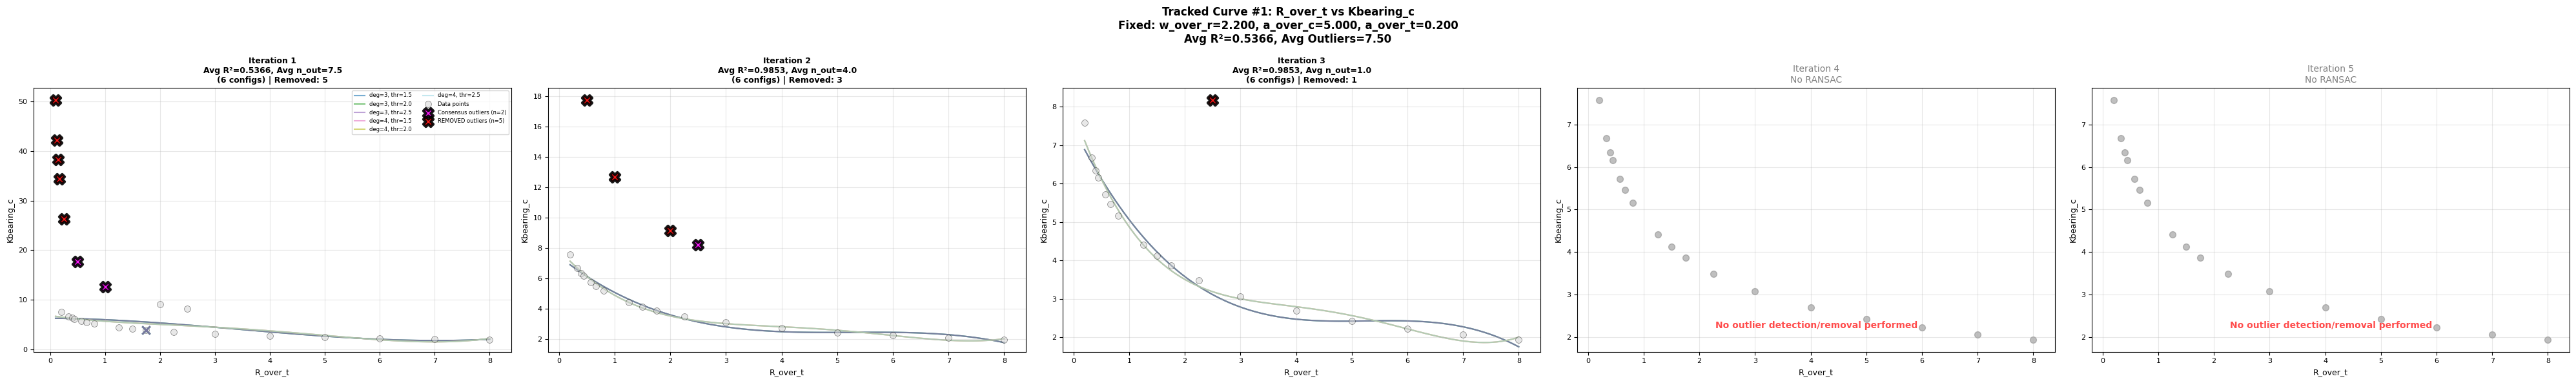


TRACKED CURVE #2
  Free param: R_over_t
  Fixed params: w_over_r=3.200, a_over_c=6.000, a_over_t=0.100
  K-target: Kbearing_c_data
  Avg R²: 0.5611, Avg Outliers: 7.50
  (6 parameter combinations)


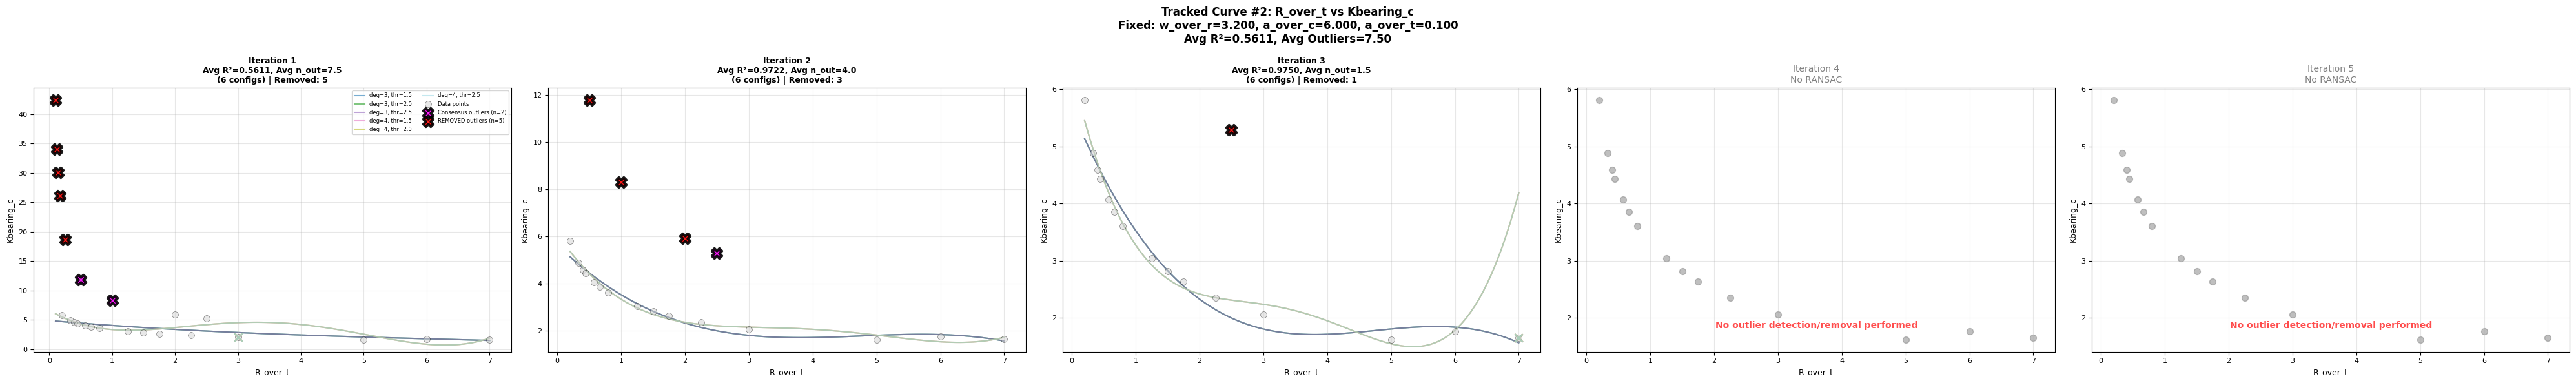


TRACKED CURVE #3
  Free param: R_over_t
  Fixed params: w_over_r=6.400, a_over_c=4.000, a_over_t=0.100
  K-target: Kbearing_c_data
  Avg R²: 0.5652, Avg Outliers: 7.00
  (6 parameter combinations)


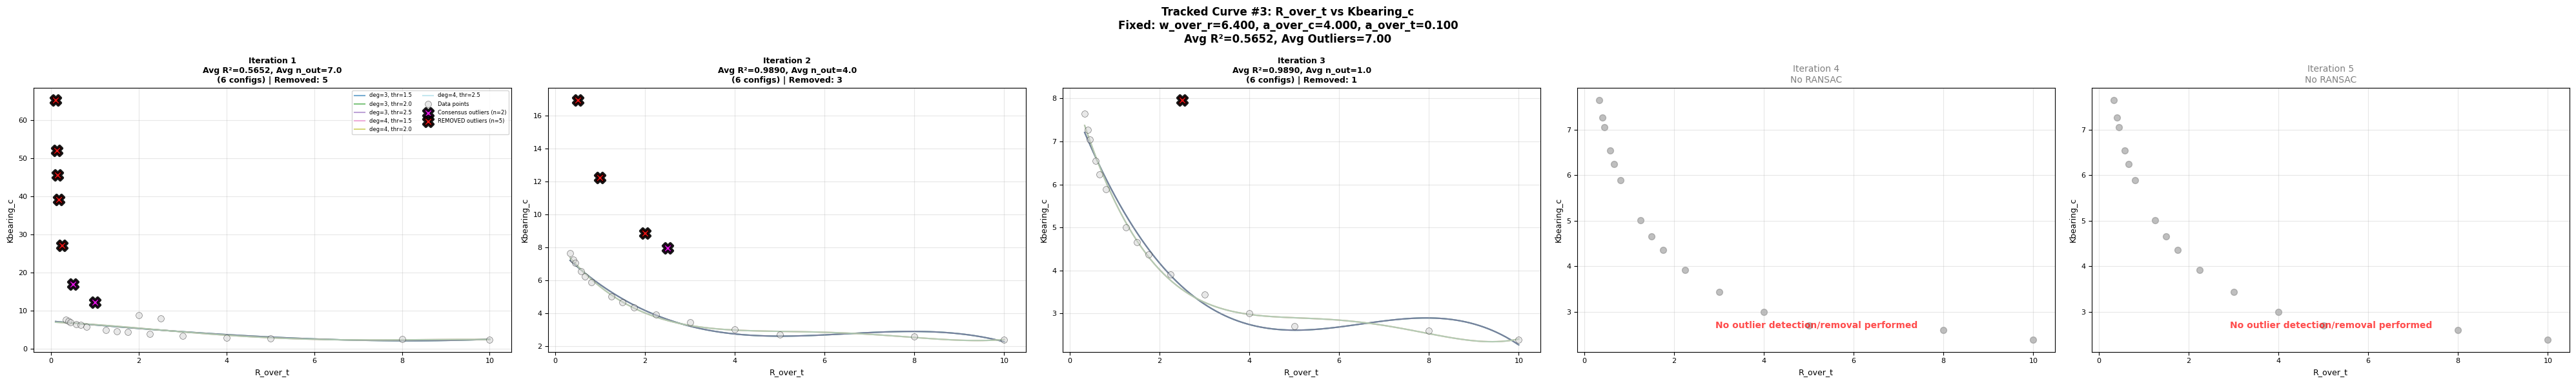


TRACKED CURVE #4
  Free param: R_over_t
  Fixed params: w_over_r=2.800, a_over_c=8.000, a_over_t=0.700
  K-target: Kbearing_c_data
  Avg R²: 0.5734, Avg Outliers: 6.50
  (6 parameter combinations)


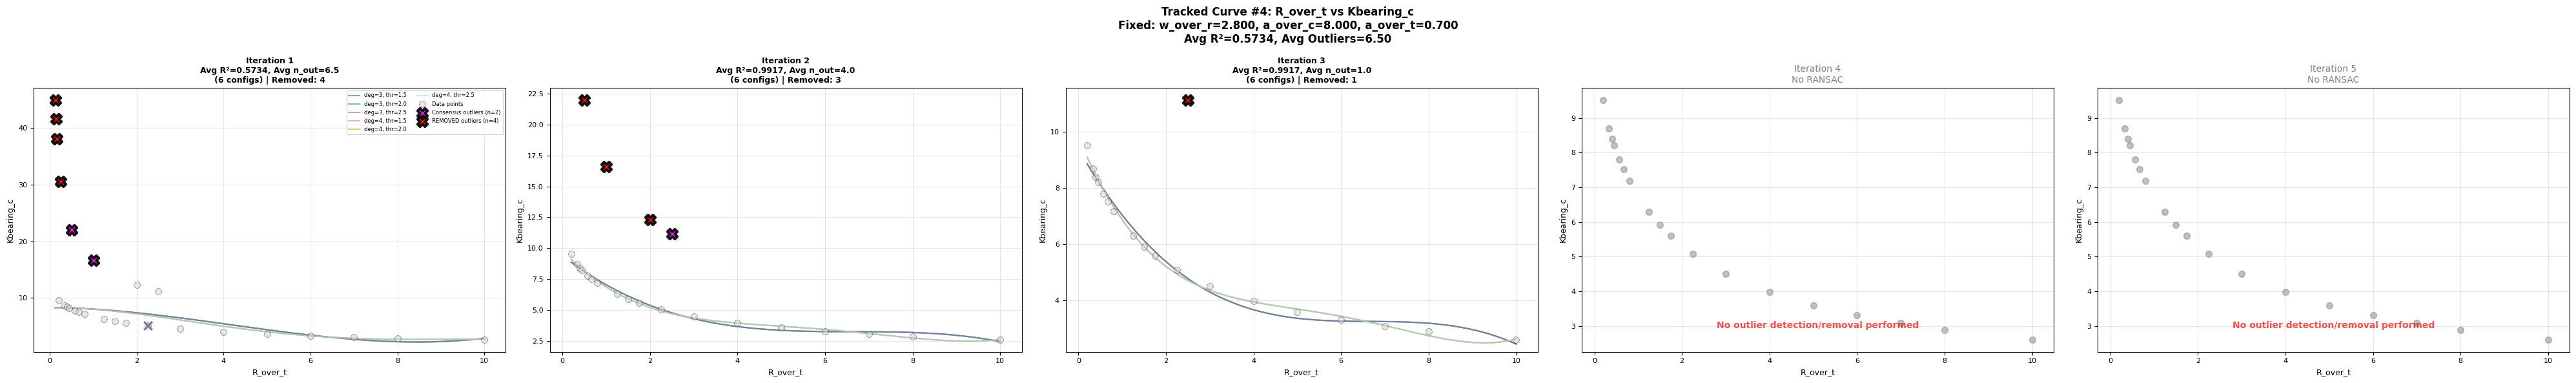


TRACKED CURVE #5
  Free param: R_over_t
  Fixed params: w_over_r=4.600, a_over_c=8.000, a_over_t=0.800
  K-target: Kbearing_c_data
  Avg R²: 0.5751, Avg Outliers: 7.50
  (6 parameter combinations)


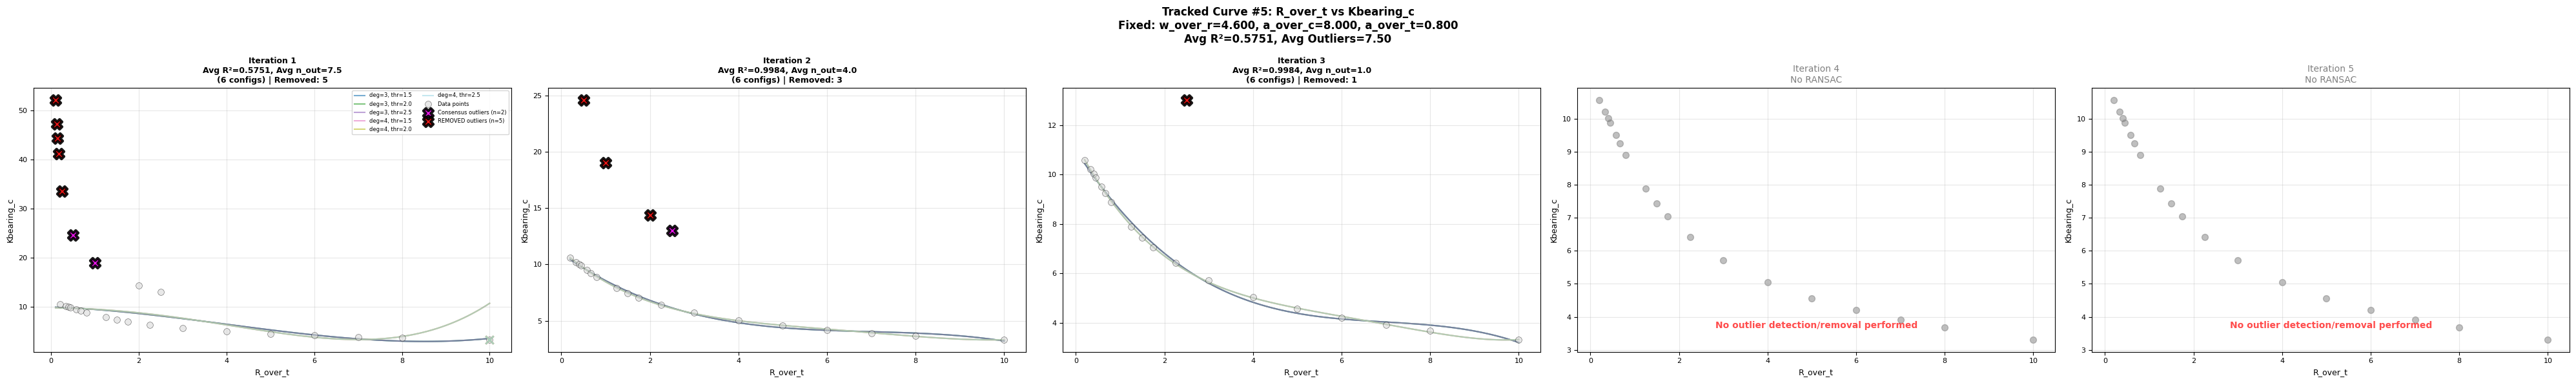


TRACKED CURVE #6
  Free param: R_over_t
  Fixed params: w_over_r=6.400, a_over_c=7.000, a_over_t=0.800
  K-target: Kbearing_c_data
  Avg R²: 0.5808, Avg Outliers: 7.50
  (6 parameter combinations)


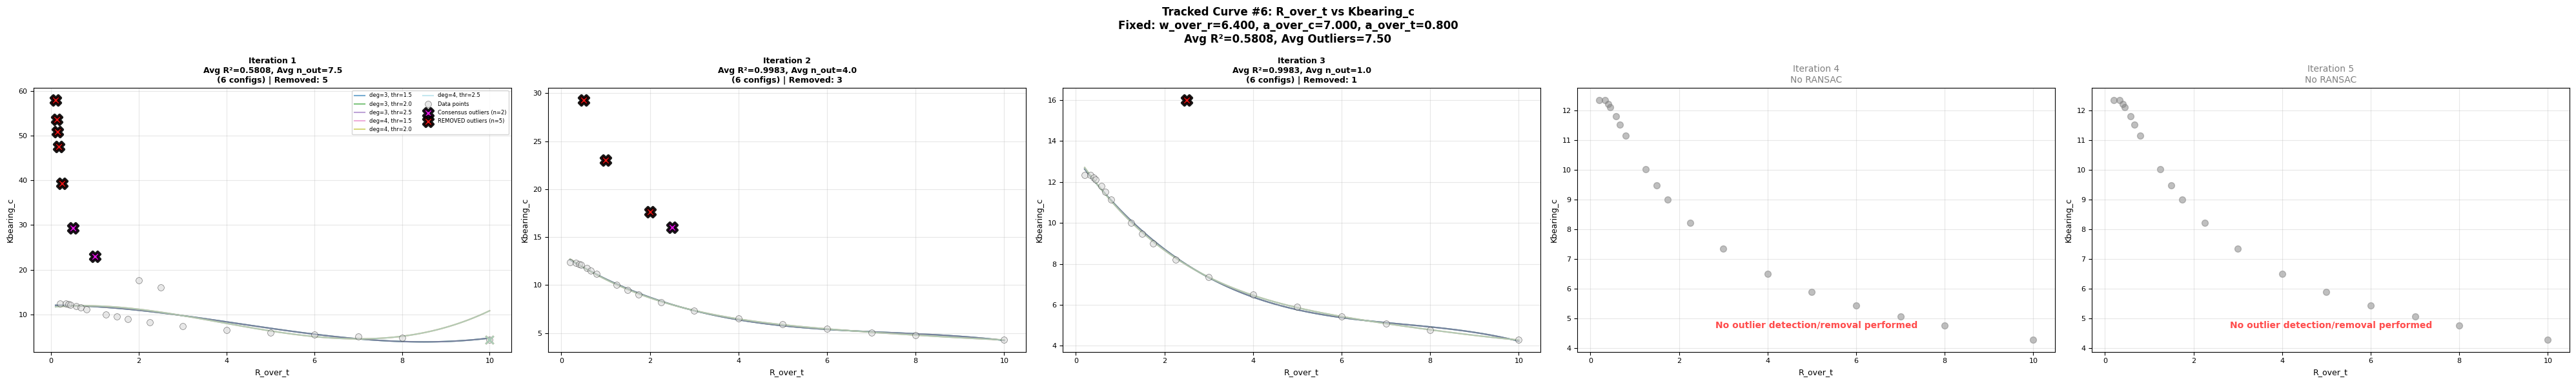


TRACKED CURVE #7
  Free param: R_over_t
  Fixed params: w_over_r=3.200, a_over_c=9.000, a_over_t=0.800
  K-target: Kbearing_c_data
  Avg R²: 0.5893, Avg Outliers: 6.50
  (6 parameter combinations)


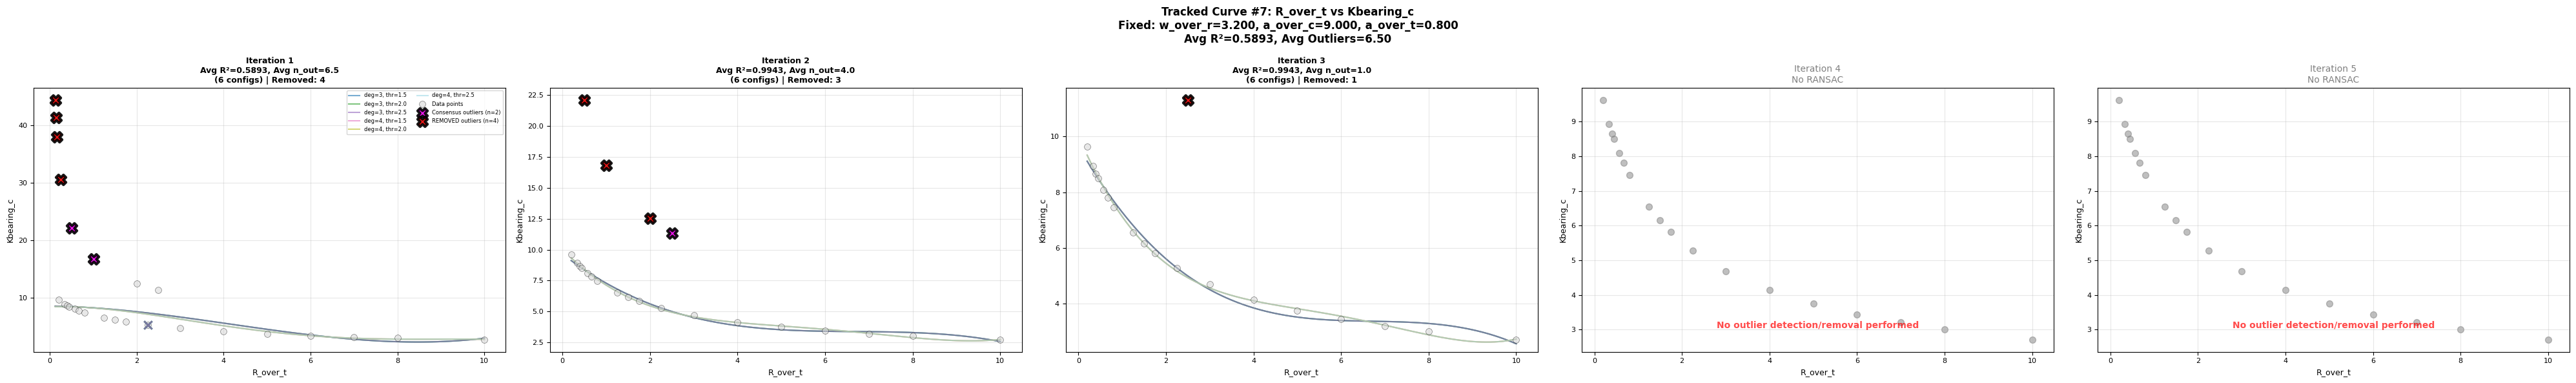


TRACKED CURVE #8
  Free param: R_over_t
  Fixed params: w_over_r=3.600, a_over_c=3.000, a_over_t=0.300
  K-target: Kbearing_c_data
  Avg R²: 0.5925, Avg Outliers: 7.50
  (6 parameter combinations)


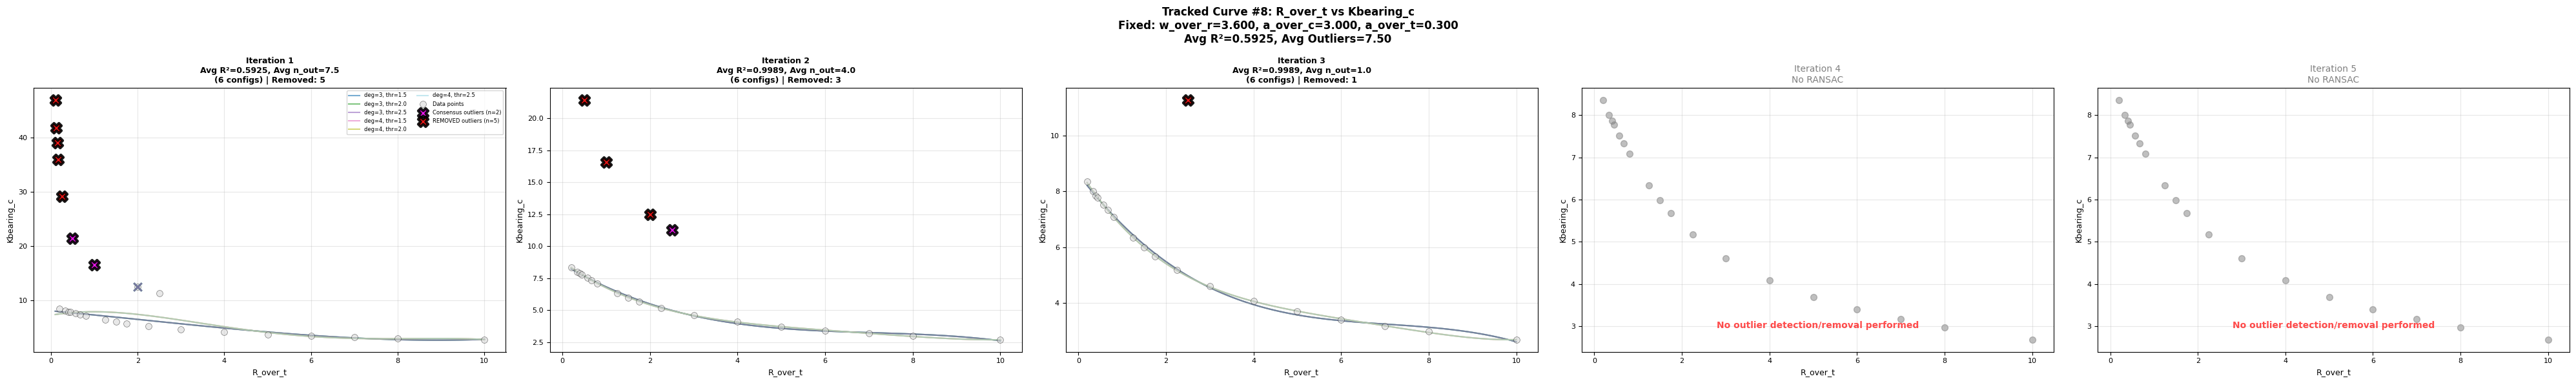


TRACKED CURVE #9
  Free param: R_over_t
  Fixed params: w_over_r=8.000, a_over_c=5.000, a_over_t=0.900
  K-target: Kbearing_c_data
  Avg R²: 0.6022, Avg Outliers: 7.50
  (6 parameter combinations)


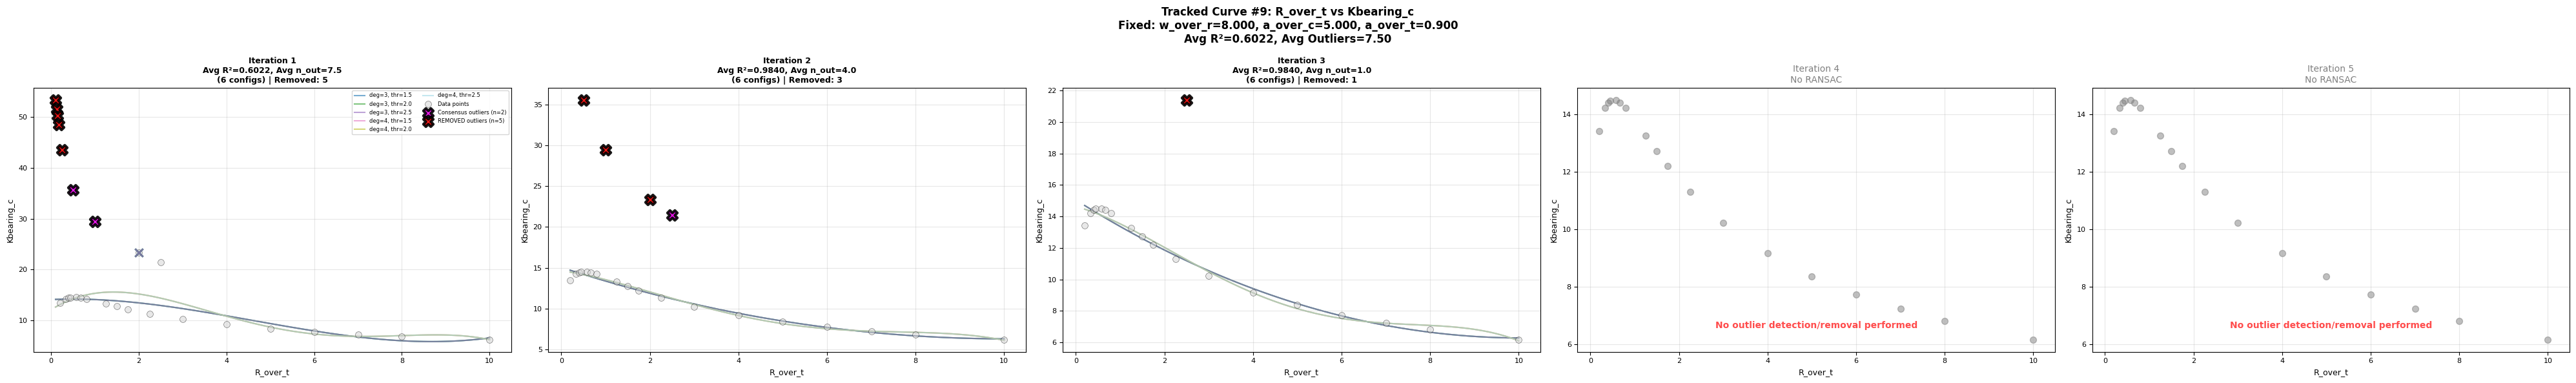


TRACKED CURVE #10
  Free param: R_over_t
  Fixed params: w_over_r=10.000, a_over_c=6.000, a_over_t=0.800
  K-target: Kbearing_c_data
  Avg R²: 0.6066, Avg Outliers: 7.00
  (6 parameter combinations)


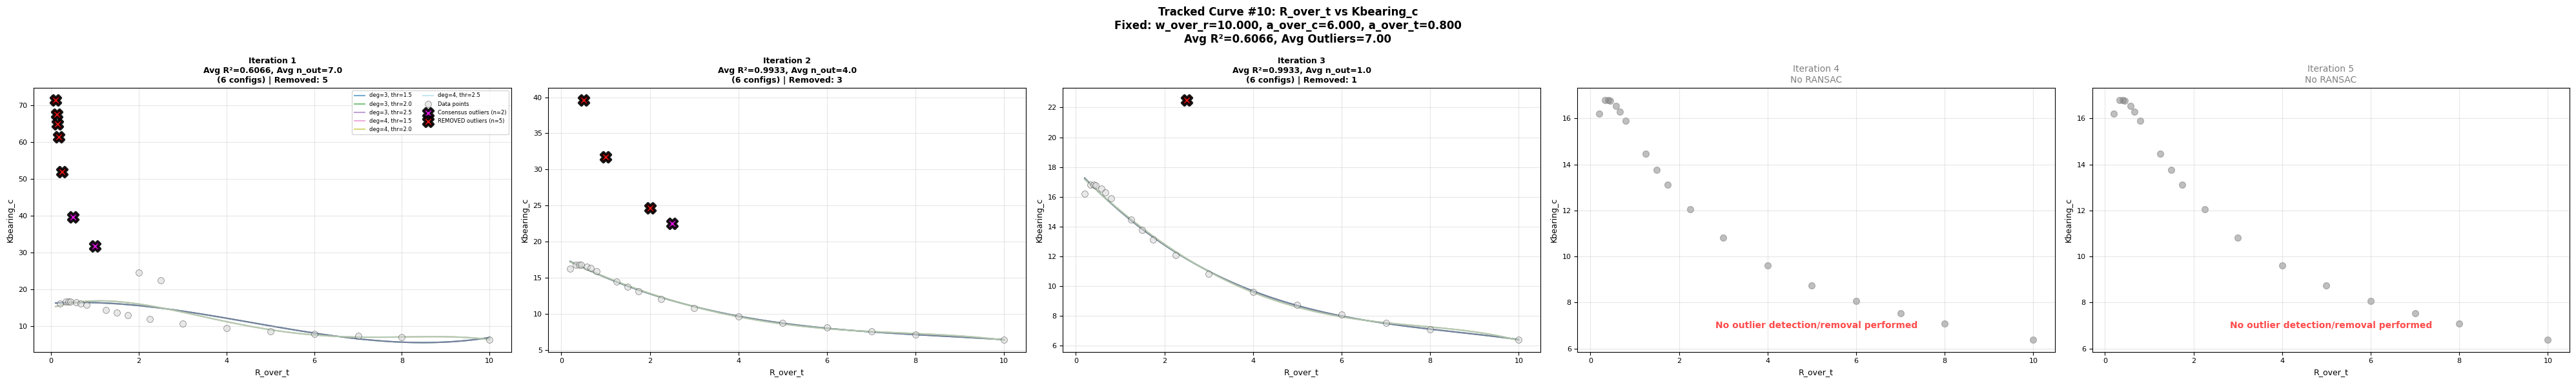


Plotted 10 tracked curves across 5 iterations


In [32]:
# Plot Iteration Progress for Worst Curves
# ============================================================================

print("="*80)
print("PLOTTING ITERATION PROGRESS FOR WORST CURVES")
print("="*80)

# Configuration
NUM_CURVES_TO_TRACK = 10  # Number of worst curves from first iteration to track
# SORT_BY = 'outliers_first'  # or 'r2_first'
SORT_BY = 'r2_first'

if len(iteration_stats) == 0:
    print("No iteration statistics available. Run the iterative loop first.")
else:
    # Get the worst curves from the FIRST iteration
    first_iteration = iteration_stats[0]
    first_reduction_dicts = first_iteration['reduction_dicts']
    
    # Collect all sweep results with AVERAGE statistics from first iteration
    sweep_rankings = []
    
    for curve_idx, d in enumerate(first_reduction_dicts):
        if "ransac_sweep_results" not in d:
            continue
        
        for k_target, sweep_result in d["ransac_sweep_results"].items():
            degree_threshold_grid = sweep_result.get('degree_threshold_grid', {})
            
            # Collect R² and outlier counts across all parameter combinations
            r2_values = []
            outlier_counts = []
            
            for poly_degree, threshold_dict in degree_threshold_grid.items():
                for threshold, config_result in threshold_dict.items():
                    if 'error' in config_result:
                        continue
                    
                    r2_inliers = config_result.get('r2_inliers', -np.inf)
                    if r2_inliers > -np.inf:
                        r2_values.append(r2_inliers)
                    
                    outlier_result = config_result.get('outlier_result', {})
                    n_outliers = outlier_result.get('n_outliers', 0)
                    outlier_counts.append(n_outliers)
            
            # Skip if no valid configurations
            if len(r2_values) == 0:
                continue
            
            # Calculate averages
            avg_r2 = np.mean(r2_values)
            avg_outliers = np.mean(outlier_counts)
            
            sweep_rankings.append({
                'curve_idx': curve_idx,
                'k_target': k_target,
                'free_param_name': d['free_param_name'],
                'fixed_params': {p: d[p] for p in ["w_over_r", "a_over_c", "a_over_t", "R_over_t"] 
                                if p in d and p != d['free_param_name']},
                'avg_r2': avg_r2,
                'avg_outliers': avg_outliers,
                'n_configs': len(r2_values)
            })
    
    # Sort by worst first based on average statistics
    if SORT_BY == 'outliers_first':
        sweep_rankings.sort(key=lambda x: (-x['avg_outliers'], x['avg_r2']))
    else:  # 'r2_first'
        sweep_rankings.sort(key=lambda x: (x['avg_r2'], -x['avg_outliers']))

    # # Filter for only w_over_r as free param
    # sweep_rankings = [ranking for ranking in sweep_rankings 
    #               if ranking["free_param_name"] == "w_over_r"]
    
    # Select worst N curves to track
    num_to_track = min(NUM_CURVES_TO_TRACK, len(sweep_rankings))
    
    if num_to_track == 0:
        print("No curves with RANSAC results found in first iteration.")
    else:
        print(f"\nTracking {num_to_track} worst curves from first iteration across {len(iteration_stats)} iterations")
        print(f"Sorted by: {SORT_BY}")
        
        # Define color palette for different parameter combinations
        from matplotlib import cm
        import matplotlib.colors as mcolors
        
        # For each tracked curve, plot it across all iterations
        for track_idx in range(num_to_track):
            worst_curve = sweep_rankings[track_idx]
            free_param_name = worst_curve['free_param_name']
            fixed_params = worst_curve['fixed_params']
            k_target = worst_curve['k_target']
            
            print(f"\n{'='*80}")
            print(f"TRACKED CURVE #{track_idx+1}")
            print(f"  Free param: {free_param_name}")
            print(f"  Fixed params: {', '.join([f'{k}={v:.3f}' for k, v in fixed_params.items()])}")
            print(f"  K-target: {k_target}")
            print(f"  Avg R²: {worst_curve['avg_r2']:.4f}, Avg Outliers: {worst_curve['avg_outliers']:.2f}")
            print(f"  ({worst_curve['n_configs']} parameter combinations)")
            print(f"{'='*80}")
            
            # Create subplot for each iteration
            n_iterations = len(iteration_stats)
            fig, axes = plt.subplots(1, n_iterations, figsize=(8 * n_iterations, 6), squeeze=False)
            axes = axes[0]  # Flatten to 1D
            
            # Track this curve through all iterations
            for iter_idx, iter_stat in enumerate(iteration_stats):
                ax = axes[iter_idx]
                iter_reduction_dicts = iter_stat['reduction_dicts']
                
                # Get indices that were actually removed in THIS iteration
                idxs_removed_this_iter = iter_stat['idxs_removed_consensus_outliers']
                
                # Find the matching curve in this iteration's reduction_dicts
                matching_curve = None
                for d in iter_reduction_dicts:
                    if d['free_param_name'] != free_param_name:
                        continue
                    
                    # Check if fixed parameters match
                    params_match = True
                    for param, value in fixed_params.items():
                        if param not in d or not np.isclose(d[param], value, rtol=1e-5):
                            params_match = False
                            break
                    
                    if params_match:
                        matching_curve = d
                        break
                
                if matching_curve is None:
                    # Curve not found in this iteration (possibly removed)
                    ax.text(0.5, 0.5, f"Iteration {iter_idx+1}\nCurve removed\n(all points filtered)", 
                           ha='center', va='center', transform=ax.transAxes,
                           fontsize=10, color='red')
                    ax.set_title(f"Iteration {iter_idx+1}\nREMOVED", fontsize=10, color='red', weight='bold')
                    ax.axis('off')
                    continue
                
                # Get data for this iteration
                data_block = matching_curve["data"]
                x = np.array(data_block["free_param_data"])
                y = np.array(data_block[k_target])
                
                # Get data_indices for this curve
                data_indices = matching_curve['data_indices']
                
                # Create mask for points that will be actually removed in this iteration
                actually_removed_mask = np.array([idx in idxs_removed_this_iter for idx in data_indices])
                # print(f"  Iteration {iter_idx+1}: Curve has {len(x)} points, {actually_removed_mask.sum()} will be removed")
                # print(f"    Data indices: {data_indices}")
                # print(f"    idxs_removed_this_iter: {sorted(idxs_removed_this_iter)}")
                
                # Clean and sort data
                valid_mask = np.isfinite(x) & np.isfinite(y)
                if valid_mask.sum() < 2:
                    ax.text(0.5, 0.5, f"Iteration {iter_idx+1}\nInsufficient data\n({valid_mask.sum()} points)", 
                           ha='center', va='center', transform=ax.transAxes,
                           fontsize=10, color='orange')
                    ax.set_title(f"Iteration {iter_idx+1}\nINSUFFICIENT DATA", fontsize=10, color='orange')
                    ax.axis('off')
                    continue
                
                x_clean = x[valid_mask]
                y_clean = y[valid_mask]
                sort_idx = np.argsort(x_clean)
                x_sorted = x_clean[sort_idx]
                y_sorted = y_clean[sort_idx]

                # x_sorted = x
                # y_sorted = y
                
                # Calculate data bounds with small margin
                x_margin = 0.05 * (x_sorted.max() - x_sorted.min())
                y_margin = 0.05 * (y_sorted.max() - y_sorted.min())
                x_min, x_max = x_sorted.min() - x_margin, x_sorted.max() + x_margin
                y_min, y_max = y_sorted.min() - y_margin, y_sorted.max() + y_margin
                
                # Get RANSAC results if available
                if "ransac_sweep_results" in matching_curve and k_target in matching_curve["ransac_sweep_results"]:
                    sweep_result = matching_curve["ransac_sweep_results"][k_target]
                    degree_threshold_grid = sweep_result.get('degree_threshold_grid', {})
                    
                    # Count total parameter combinations
                    n_configs = sum(len(thresh_dict) for thresh_dict in degree_threshold_grid.values())
                    
                    if n_configs > 0:
                        # Generate color palette for parameter combinations
                        colors = cm.tab20(np.linspace(0, 1, n_configs))
                        color_idx = 0
                        
                        # Find consensus outliers for this curve
                        consensus_outliers_mask = np.zeros(len(x_sorted), dtype=bool)
                        outlier_votes = np.zeros(len(x_sorted), dtype=int)
                        total_configs = 0
                        
                        for poly_degree, threshold_dict in degree_threshold_grid.items():
                            for threshold, config_result in threshold_dict.items():
                                if 'error' in config_result:
                                    continue
                                
                                outlier_result = config_result.get('outlier_result', {})
                                outlier_mask = outlier_result.get('outlier_mask', None)
                                
                                if outlier_mask is not None:
                                    outlier_votes += outlier_mask.astype(int)
                                    total_configs += 1
                        
                        if total_configs > 0:
                            # Consensus: marked by majority of configs
                            consensus_outliers_mask = outlier_votes >= (total_configs * CONSENSUS_THRESHOLD)

                        # Plot all parameter combinations
                        for poly_degree in sorted(degree_threshold_grid.keys()):
                            threshold_dict = degree_threshold_grid[poly_degree]
                            
                            for threshold in sorted(threshold_dict.keys()):
                                config_result = threshold_dict[threshold]
                                
                                if 'error' in config_result:
                                    continue
                                
                                outlier_result = config_result.get('outlier_result', {})
                                r2_inliers = config_result.get('r2_inliers', -np.inf)
                                
                                if outlier_result.get('coeffs') is None:
                                    continue
                                
                                # Get color for this configuration
                                config_color = colors[color_idx]
                                color_idx += 1
                                
                                # Get outlier mask for this config
                                outlier_mask = outlier_result.get('outlier_mask', None)
                                if outlier_mask is None:
                                    outlier_mask = np.zeros_like(x_sorted, dtype=bool)
                                
                                # Plot the fit line ONLY within data bounds
                                coeffs = outlier_result['coeffs']
                                x_fit = np.linspace(x_sorted.min(), x_sorted.max(), 100)
                                y_fit = np.polyval(coeffs, x_fit)
                                
                                label = f"deg={poly_degree}, thr={threshold:.1f}"
                                ax.plot(x_fit, y_fit, '-', color=config_color, 
                                       linewidth=1.5, alpha=0.6, label=label, zorder=1)
                                
                                # Plot outliers for this configuration (same color as fit)
                                if outlier_mask.sum() > 0:
                                    # Non-consensus outliers for this config
                                    non_consensus_outliers = outlier_mask & ~consensus_outliers_mask
                                    if non_consensus_outliers.sum() > 0:
                                        ax.scatter(x_sorted[non_consensus_outliers], 
                                                 y_sorted[non_consensus_outliers],
                                                 c=[config_color], s=80, marker='x', 
                                                 linewidths=2, alpha=0.7, zorder=3)
                        
                        # Plot all data points (inliers) in gray
                        ax.scatter(x_sorted, y_sorted, c='lightgray', s=50, 
                                 alpha=0.5, label='Data points', zorder=2, edgecolors='black', linewidths=0.5)
                        
                        # Separate consensus outliers into those actually removed vs not removed
                        consensus_not_removed = consensus_outliers_mask & ~actually_removed_mask
                        consensus_and_removed = consensus_outliers_mask & actually_removed_mask
                        
                        # Plot consensus outliers NOT removed in magenta
                        if consensus_not_removed.sum() > 0:
                            ax.scatter(x_sorted[consensus_not_removed], 
                                     y_sorted[consensus_not_removed],
                                     c='magenta', s=120, marker='X', 
                                     linewidths=3, alpha=0.9, 
                                     label=f'Consensus outliers (n={consensus_not_removed.sum()})',
                                     zorder=4, edgecolors='black')
                        
                        # Plot consensus outliers that ARE removed in red
                        if consensus_and_removed.sum() > 0:
                            ax.scatter(x_sorted[consensus_and_removed], 
                                     y_sorted[consensus_and_removed],
                                     c='red', s=120, marker='X', 
                                     linewidths=3, alpha=0.9, 
                                     label=f'REMOVED outliers (n={consensus_and_removed.sum()})',
                                     zorder=5, edgecolors='black')

                        
                        # Calculate average R² and outliers for title
                        r2_values = []
                        outlier_counts = []
                        for poly_degree, threshold_dict in degree_threshold_grid.items():
                            for threshold, config_result in threshold_dict.items():
                                if 'error' not in config_result:
                                    r2_val = config_result.get('r2_inliers', -np.inf)
                                    if r2_val > -np.inf:
                                        r2_values.append(r2_val)
                                    
                                    outlier_result = config_result.get('outlier_result', {})
                                    outlier_counts.append(outlier_result.get('n_outliers', 0))
                        
                        avg_r2 = np.mean(r2_values) if r2_values else -np.inf
                        avg_outliers = np.mean(outlier_counts) if outlier_counts else 0
                        
                        n_removed_this_curve = actually_removed_mask.sum()
                        
                        ax.set_title(f"Iteration {iter_idx+1}\n" +
                                   f"Avg R²={avg_r2:.4f}, Avg n_out={avg_outliers:.1f}\n" +
                                   f"({len(r2_values)} configs) | Removed: {n_removed_this_curve}", 
                                   fontsize=9, weight='bold')
                    else:
                        # No valid configurations
                        ax.scatter(x_sorted, y_sorted, c='gray', s=50, alpha=0.5)
                        ax.set_title(f"Iteration {iter_idx+1}\nNo valid configs", 
                                   fontsize=10, color='gray')
                else:
                    # No RANSAC results
                    ax.scatter(x_sorted, y_sorted, c='gray', s=50, alpha=0.5)
                    ax.set_title(f"Iteration {iter_idx+1}\nNo RANSAC", 
                               fontsize=10, color='gray')

                # If requires_outlier_detection is false, overlay in red text that no outlier detection/removal was performed
                if not matching_curve.get('requires_outlier_detection', True):
                    ax.text(0.5, 0.1, "No outlier detection/removal performed", 
                           ha='center', va='center', transform=ax.transAxes,
                            fontsize=10, color='red', weight='bold', alpha=0.7)
                    

                # Set axis limits based on data bounds (not fit curves)
                ax.set_xlim(x_min, x_max)
                ax.set_ylim(y_min, y_max)
                
                ax.set_xlabel(free_param_name, fontsize=9)
                ax.set_ylabel(k_target.replace('_data', ''), fontsize=9)
                ax.grid(True, alpha=0.3)
                ax.tick_params(labelsize=8)
                
                # Add legend only for first iteration (and make it smaller)
                if iter_idx == 0:
                    ax.legend(fontsize=6, loc='best', ncol=2)
            
            # Overall title
            fig.suptitle(f"Tracked Curve #{track_idx+1}: {free_param_name} vs {k_target.replace('_data', '')}\n" +
                        f"Fixed: {', '.join([f'{k}={v:.3f}' for k, v in fixed_params.items()])}\n" +
                        f"Avg R²={worst_curve['avg_r2']:.4f}, Avg Outliers={worst_curve['avg_outliers']:.2f}", 
                        fontsize=12, weight='bold')
            
            plt.tight_layout()
            plt.show()
        
        print(f"\n{'='*80}")
        print(f"Plotted {num_to_track} tracked curves across {len(iteration_stats)} iterations")
        print(f"{'='*80}")

In [ ]:
# Remove consensus outliers from original dataset based on iteration_stats
# ============================================================================

import pickle
import numpy as np

print("="*80)
print("REMOVING CONSENSUS OUTLIERS FROM ORIGINAL DATASET")
print("="*80)

# Load iteration_stats (if not already in memory)
# with open("iteration_stats_temp.pkl", "rb") as f:
#     iteration_stats = pickle.load(f)

# Load the original full dataset
all_params_all_Ks = np.load("all_params_all_Ks_vertex_flagged.npy")
print(f"\nOriginal dataset shape: {all_params_all_Ks.shape}")

# Collect all indices to remove across all iterations
all_indices_to_remove = set()

print(f"\nCollecting indices from {len(iteration_stats)} iterations...")

for iter_stat in iteration_stats:
    iter_num = iter_stat['iteration']
    idxs_removed = iter_stat['idxs_removed_consensus_outliers']
    
    print(f"  Iteration {iter_num}: {len(idxs_removed)} indices to remove")
    all_indices_to_remove.update(idxs_removed)

print(f"\nTotal unique indices to remove: {len(all_indices_to_remove)}")

# Create boolean mask for points to keep
keep_mask = np.ones(len(all_params_all_Ks), dtype=bool)

for idx in all_indices_to_remove:
    if 0 <= idx < len(all_params_all_Ks):
        keep_mask[idx] = False

# Apply mask to create cleaned dataset
all_params_all_Ks_outliers_removed = all_params_all_Ks[keep_mask]

# Summary statistics
n_original = len(all_params_all_Ks)
n_cleaned = len(all_params_all_Ks_outliers_removed)
n_removed = n_original - n_cleaned

print(f"\n{'='*80}")
print("DATASET CLEANING SUMMARY")
print(f"{'='*80}")
print(f"Original dataset size: {n_original} points")
print(f"Cleaned dataset size: {n_cleaned} points")
print(f"Points removed: {n_removed} ({100*n_removed/n_original:.2f}%)")

# Save the cleaned dataset
output_filename = "all_params_all_Ks_outliers_removed.npy"
np.save(output_filename, all_params_all_Ks_outliers_removed)
print(f"\nCleaned dataset saved to: {output_filename}")
print(f"{'='*80}")

In [ ]:
# Search for a specified curve within a reduction_dict object
import pickle
import numpy as np

# Load the reduction dicts
with open("reduction_dicts_outliers_only.pkl", "rb") as f:
    reduction_dicts_outliers_only = pickle.load(f)

# Define the parameters to search for
target_free_param = "R_over_t"
target_fixed_params = {
    "w_over_r": 1.800,
    "a_over_c": 4.000,
    "a_over_t": 0.100
}

print("="*80)
print("SEARCHING FOR CURVE IN REDUCTION DICTS")
print("="*80)
print(f"Target free parameter: {target_free_param}")
print(f"Target fixed parameters:")
for param, value in target_fixed_params.items():
    print(f"  {param} = {value:.3f}")
print("="*80)

# Search through all reduction dicts
matches = []

for idx, d in enumerate(reduction_dicts_outliers_only):
    # Check if free parameter matches
    if d["free_param_name"] != target_free_param:
        continue
    
    # Check if all fixed parameters match (with tolerance for floating point)
    params_match = True
    for param, target_value in target_fixed_params.items():
        if param not in d:
            params_match = False
            break
        
        # Use np.isclose for floating point comparison
        if not np.isclose(d[param], target_value, rtol=1e-5):
            params_match = False
            break
    
    if params_match:
        matches.append(idx)
        print(f"\n✓ MATCH FOUND at index {idx}")
        print(f"  Free parameter: {d['free_param_name']}")
        print(f"  Fixed parameters:")
        for param in ["w_over_r", "a_over_c", "a_over_t", "R_over_t"]:
            if param in d and param != d["free_param_name"]:
                print(f"    {param} = {d[param]:.6f}")
        
        # Print data info
        if "data" in d:
            n_points = len(d["data"]["free_param_data"])
            print(f"  Number of data points: {n_points}")
            print(f"  Data indices: {d['data_indices']}")
            
            # Print free parameter range
            free_vals = d["data"]["free_param_data"]
            print(f"  {target_free_param} range: [{np.min(free_vals):.4f}, {np.max(free_vals):.4f}]")
        
        # Check for RANSAC results
        if "ransac_sweep_results" in d:
            print(f"  RANSAC results available for K-targets: {list(d['ransac_sweep_results'].keys())}")
            for k_target, sweep_result in d["ransac_sweep_results"].items():
                if sweep_result['best_config'] is not None:
                    best_config = sweep_result['best_config']
                    print(f"    {k_target}:")
                    print(f"      Best degree: {best_config['degree']}")
                    print(f"      Best threshold: {best_config['threshold']:.2f}")
                    print(f"      R² (inliers): {best_config['r2_inliers']:.4f}")
                    print(f"      Number of outliers: {best_config['outlier_result']['n_outliers']}")

print(f"\n{'='*80}")
if len(matches) == 0:
    print("NO MATCHES FOUND")
    print("\nSearching for similar curves...")
    
    # Search for curves with same free parameter
    similar_free = []
    for idx, d in enumerate(reduction_dicts_outliers_only):
        if d["free_param_name"] == target_free_param:
            similar_free.append((idx, d))
    
    print(f"\nFound {len(similar_free)} curves with free parameter = {target_free_param}")
    if len(similar_free) > 0:
        print("\nShowing first 5:")
        for idx, d in similar_free[:5]:
            print(f"\n  Index {idx}:")
            for param in ["w_over_r", "a_over_c", "a_over_t"]:
                if param in d:
                    print(f"    {param} = {d[param]:.6f}")
    
elif len(matches) == 1:
    print(f"FOUND 1 MATCH at index: {matches[0]}")
else:
    print(f"FOUND {len(matches)} MATCHES at indices: {matches}")
    print("WARNING: Multiple matches found - parameters may not be unique!")

print("="*80)

# Return the match(es)
if len(matches) > 0:
    print(f"\nTo access the curve(s):")
    for match_idx in matches:
        print(f"  curve = reduction_dicts_outliers_only[{match_idx}]")